# Анализ классифицированного каталога LPS SyCLoPS

Этот ноутбук предназначен для загрузки, изучения и фильтрации данных из классифицированного каталога SyCLoPS. В основе лежат инструкции из руководства пользователя.

**Файл:** `SyCLoPS_classified_ERA5_1940_2024_3hr.parquet`

## 1. Настройка окружения и импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения pandas
pd.set_option('display.max_columns', 15)
pd.set_option('display.max_rows', 20)

print("Библиотеки успешно загружены.")

Библиотеки успешно загружены.


## 2. Загрузка каталога

Укажите путь к вашему файлу `.parquet` и загрузите его. Для работы с форматом Parquet необходим пакет `pyarrow`.

In [2]:
# Укажите фактический путь к вашему файлу
path_init = f'/storage/thalassa/users/vkoshkina'
path_dir_data = f'{path_init}/data/'

file_path = f'{path_dir_data}/SyCLoPS/SyCLoPS_classified_ERA5_1940_2024_3hr.parquet'


try:
    df = pd.read_parquet(file_path)
    print(f"Каталог успешно загружен. Количество записей (узлов LPS): {len(df):,}")
except FileNotFoundError:
    print(f"Ошибка: Файл по пути '{file_path}' не найден. Пожалуйста, проверьте путь.")
except ImportError:
    print("Ошибка: Для чтения .parquet необходим пакет 'pyarrow'. Установите его: pip install pyarrow")

Каталог успешно загружен. Количество записей (узлов LPS): 12,685,049


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import warnings
warnings.filterwarnings('ignore')

# Путь к данным
path_init = '/storage/thalassa/users/vkoshkina'
path_dir_data = f'{path_init}/data/'
file_path = f'{path_dir_data}/SyCLoPS/SyCLoPS_classified_ERA5_1940_2025_3hr.parquet'
# file_path = f'{path_dir_data}/SyCLoPS/SyCLoPS_input_ERA5_1940_2024_3hr.parquet'


# Загрузка данных
print("Загрузка данных...")
dfc = pd.read_parquet(file_path)
print(f"Всего записей: {len(dfc)}")
dfc['LON'] = dfc['LON'] - 180
dfc


Загрузка данных...
Всего записей: 13416358


,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,Transition_Zone,Track_Info,LPSAREA,i,j,distance,direction
0,0,-142.00,74.75,1940-01-01 00:00:00,99764.187500,18.176910,-0.083058,...,False,Track,0,152,61,NaN,NaN
1,0,-141.25,75.25,1940-01-01 03:00:00,99729.750000,19.374901,0.321518,...,False,Track,0,155,59,59.639221,20.855745
2,0,-143.00,75.50,1940-01-01 06:00:00,99653.750000,19.311020,-0.872678,...,False,Track,0,148,58,56.448521,300.345459
3,0,-145.00,75.50,1940-01-01 09:00:00,99589.882812,19.725540,0.592564,...,False,Track,0,140,58,55.679321,270.968140
4,0,-146.75,75.25,1940-01-01 12:00:00,99357.117188,19.693110,0.701780,...,False,Track,0,133,59,56.448521,241.347855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13416353,702764,3.75,35.25,2025-12-31 09:00:00,101582.101562,13.401810,0.125010,...,False,Track,0,735,219,95.054321,28.533136
13416354,702764,3.75,36.25,2025-12-31 12:00:00,101518.203125,14.132020,-0.026855,...,False,Track,55070,735,215,111.194923,0.000000
13416355,702764,4.00,37.00,2025-12-31 15:00:00,101494.101562,14.778260,0.203135,...,False,Track,0,736,212,86.328705,14.902556
13416356,702764,4.00,37.50,2025-12-31 18:00:00,101495.796875,16.283680,-0.018884,...,False,Track,129275,736,210,55.597462,0.000000


In [74]:
dfc.columns

Index(['TID', 'LON', 'LAT', 'ISOTIME', 'MSLP', 'WS', 'ZS', 'Short_Label',
       'Adjusted_Label', 'Tropical_Flag', 'Transition_Zone', 'Track_Info',
       'LPSAREA', 'i', 'j', 'distance', 'direction'],
      dtype='object')

In [4]:
# Определение региона Северной Атлантики
minlat = 0.0
maxlat = 71.0
minlon = -110.0
maxlon = 15.0

# Фильтрация по региону и периоду
print("Фильтрация данных...")
df_atlantic = dfc[
    (dfc['LAT'] >= minlat) & 
    (dfc['LAT'] <= maxlat) & 
    (dfc['LON'] >= minlon) & 
    (dfc['LON'] <= maxlon)
]

# Фильтрация по времени (1979-2024)
df_atlantic = df_atlantic[
    (df_atlantic['ISOTIME'] >= '1979-01-01') & 
    (df_atlantic['ISOTIME'] <= '2024-12-31')
]

print(f"Записей в регионе за период 1979-2024: {len(df_atlantic)}")
df_atlantic

Фильтрация данных...
Записей в регионе за период 1979-2024: 1162023


,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,Transition_Zone,Track_Info,LPSAREA,i,j,distance,direction
5831357,290905,-77.75,27.75,1979-01-01 00:00:00,101487.80,4.656367,21496.630000,...,0.0,Track,0,409,249,0.000000,0.000000
5831358,290905,-78.00,27.75,1979-01-01 03:00:00,101684.60,7.324174,21528.150000,...,0.0,Track,0,408,249,24.601530,270.058202
5831359,290905,-79.25,28.50,1979-01-01 06:00:00,101213.70,5.680164,35260.980000,...,0.0,Track,0,403,246,148.258590,304.522132
5831360,290905,-78.50,26.50,1979-01-01 09:00:00,101021.20,6.703320,15223.790000,...,0.0,Track,0,406,254,234.367822,161.427075
5831361,290905,-78.50,26.50,1979-01-01 12:00:00,101150.60,3.733455,15223.790000,...,0.0,Track,0,406,254,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12684992,628017,2.50,40.25,2024-12-31 00:00:00,97917.56,29.060850,1.092285,...,0.0,Track_SS(STLC)_PL(PTLC),1375579,730,199,171.041102,60.260350
12685000,628018,-67.50,7.50,2024-12-30 12:00:00,100846.40,13.489280,14.018070,...,0.0,Track,407476,450,330,NaN,NaN
12685001,628018,-67.25,7.00,2024-12-30 15:00:00,100947.40,12.882620,10.490720,...,0.0,Track,386344,451,332,62.060737,153.602591
12685002,628018,-67.00,6.75,2024-12-30 21:00:00,100740.40,10.546720,-14.165530,...,0.0,Track,382863,452,333,39.172244,198.331038


In [7]:
# Получение списка уникальных треков TC
all_tracks = df_atlantic['TID'].unique()
print(f"Количество уникальных треков в Атлантике: {len(all_tracks)}")

# Фильтрация по времени (1979-2024)
df_atlantic_2010 = df_atlantic[
    (df_atlantic['ISOTIME'].dt.year == 2010)]

# Получение списка уникальных треков TC
all_tracks = df_atlantic_2010['TID'].unique()
print(f"Количество уникальных треков в Атлантике за 2010: {len(all_tracks)}")

Количество уникальных треков в Атлантике: 64641
Количество уникальных треков в Атлантике за 2010: 1377


In [39]:
# ============================================================
# ВЫБОР ОСНОВНЫХ ТИПОВ SyCLoPS
# ============================================================

syclops_types = {
    'MS': 'Monsoonal Systems',
    'SS(STLC)': 'Subtropical Tropical-Like Cyclones',
    'PL(PTLC)': 'Polar Tropical-Like Cyclones',
    'TC': 'Tropical Cyclones',
}

# ------------------------------------------------------------
# Смотрим, какие значения реально есть
# ------------------------------------------------------------

print("\nУникальные Track_Info:")
print(
    df_atlantic_2010['Track_Info']
    .value_counts(dropna=False)
)

print("\nУникальные Short_Label:")
print(
    df_atlantic_2010['Short_Label']
    .value_counts(dropna=False)
)


Уникальные Track_Info:
Track_Info
Track                    15258
Track_QS                  3686
Track_SS(STLC)             973
Track_PL(PTLC)             905
Track_MS                   605
                         ...  
Track_TC_SS(STLC)_EXT        1
Track_TC_EXT_QS              1
Track_TC_MS_EXT              1
Track_HT_SS(STLC)_TT         1
Track_HT_SS(STLC)_EXT        1
Name: count, Length: 23, dtype: int64

Уникальные Short_Label:
Short_Label
EX          9627
THL         2303
DSE         2302
HATHL       2034
HAL         1014
DST          983
TLO          957
DSD          887
DOTHL        719
TC           630
TD           592
SC           565
TLO(ML)      388
SS(STLC)     385
TD(MD)       359
PL(PTLC)     272
HTC           37
Name: count, dtype: int64


In [46]:
df_atlantic_2010['Track_Info'].unique()

array(['Track_QS', 'Track', 'Track_SS(STLC)', 'Track_SS(STLC)_PL(PTLC)',
       'Track_SS(STLC)_QS', 'Track_PL(PTLC)', 'Track_TC',
       'Track_SS(STLC)_PL(PTLC)_QS', 'Track_PL(PTLC)_QS', 'Track_MS_QS',
       'Track_TC_SS(STLC)', 'Track_TC_SS(STLC)_EXT', 'Track_MS',
       'Track_TC_MS', 'Track_TC_SS(STLC)_PL(PTLC)',
       'Track_TC_SS(STLC)_PL(PTLC)_EXT', 'Track_TC_MS_EXT', 'Track_TC_QS',
       'Track_TC_EXT_QS', 'Track_TC_MS_QS', 'Track_HT_SS(STLC)',
       'Track_HT_SS(STLC)_TT', 'Track_HT_SS(STLC)_EXT'], dtype=object)

In [48]:
# ============================================================
# SyCLoPS classification
# ============================================================

TYPE_PATTERNS = {
    "TC": "TC",
    "STLC": "SS(STLC)",
    "PTLC": "PL(PTLC)",
    "MS": "MS",
}


def get_syclops_types(track_info):

    if pd.isna(track_info):
        return []

    info = str(track_info).strip()

    # Убираем Track_
    if info.startswith('Track_'):
        info = info[6:]

    types = []

    if 'SS(STLC)' in info:
        types.append('STLC')

    if 'PL(PTLC)' in info:
        types.append('PTLC')

    if 'MS' in info:
        types.append('MS')

    if 'TC' in info:
        types.append('TC')

    return types


def get_syclops_primary_type(track_info):

    types = get_syclops_types(track_info)

    # Приоритет для взаимоисключающей классификации
    for type_name in ['TC', 'STLC', 'PTLC', 'MS']:
        if type_name in types:
            return type_name

    return None

In [53]:
df_atlantic_2010['SyCLoPS_types'] = (
    df_atlantic_2010['Track_Info']
    .apply(get_syclops_types)
)

df_atlantic_2010['SyCLoPS_primary_type'] = (
    df_atlantic_2010['Track_Info']
    .apply(get_syclops_primary_type)
)
df_atlantic_2010.dropna()

,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,i,j,distance,direction,Track_Group,SyCLoPS_types,SyCLoPS_primary_type
10437335,517554,-10.00,35.25,2010-01-01 00:00:00,97899.00,24.97912,1.389160,...,680,219,221.543050,67.247219,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10437336,517554,-8.25,36.25,2010-01-01 03:00:00,97584.56,24.29938,-2.899902,...,687,215,193.138207,54.341830,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10437337,517554,-6.50,37.00,2010-01-01 06:00:00,97335.56,24.75166,-3.895996,...,694,212,177.038286,61.377438,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10437338,517554,-5.00,37.50,2010-01-01 09:00:00,97207.31,24.64773,-1.806152,...,700,210,143.935749,66.825282,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10437339,517554,-3.50,38.00,2010-01-01 12:00:00,97136.25,22.98039,1.979004,...,706,208,143.118817,66.683081,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10585459,524807,-24.75,40.00,2010-12-30 00:00:00,97654.38,23.44595,2.873535,...,621,200,172.917128,80.108783,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10585460,524807,-23.25,39.75,2010-12-30 03:00:00,97497.38,24.09408,4.713379,...,627,201,130.985966,101.771170,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10585461,524807,-21.25,39.75,2010-12-30 06:00:00,97537.19,23.31803,-2.645996,...,635,201,170.979073,89.360523,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC
10585462,524807,-19.25,39.75,2010-12-30 09:00:00,97695.75,21.91147,-2.802246,...,643,201,170.979073,89.360523,Subtropical Tropical-Like Cyclones (STLC),[STLC],STLC


In [54]:
track_types = (
    df_atlantic_2010[
        ['TID', 'Track_Info', 'SyCLoPS_primary_type']
    ]
    .drop_duplicates('TID')
)

print(
    track_types['SyCLoPS_primary_type']
    .value_counts(dropna=False)
)

SyCLoPS_primary_type
None    1189
STLC      90
PTLC      54
MS        24
TC        20
Name: count, dtype: int64


In [72]:
# 1. Преобразуем ISOTIME в datetime
df_atlantic_2010['ISOTIME'] = pd.to_datetime(df_atlantic_2010['ISOTIME'])

# 2. Для каждого TID вычисляем время жизни (max - min)
lifetime_per_tid = df_atlantic_2010.groupby('TID').agg(
    lifetime=('ISOTIME', lambda x: (x.max() - x.min()).total_seconds() / 3600 / 24),
    primary_type=('SyCLoPS_primary_type', 'first')  # берём тип из первой записи TID
).reset_index()

# 3. Группируем по primary_type и считаем среднее время жизни
avg_lifetime_by_type = lifetime_per_tid.groupby('primary_type')['lifetime'].mean().reset_index()

# Результат
print(avg_lifetime_by_type)

  primary_type  lifetime
0           MS  4.385417
1         PTLC  2.724537
2         STLC  2.640278
3           TC  8.581250


In [56]:
def save_syclops_tempest_format_by_year(
    df,
    year,
    syclops_type,
    output_dir,
):
    """
    Сохраняет SyCLoPS-треки одного типа за один год
    в формате TempestExtremes.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame с SyCLoPS.
        Должны присутствовать:
        TID, ISOTIME, LON, LAT, MSLP, WS,
        SyCLoPS_primary_type

    year : int
        Год.

    syclops_type : str
        Один из:
        'TC', 'STLC', 'PTLC', 'MS'

    output_dir : str
        Корневая директория для сохранения.
    """

    # --------------------------------------------------------
    # Фильтрация по году и типу
    # --------------------------------------------------------

    df_filtered = df[
        (df["ISOTIME"].dt.year == year)
        &
        (df["SyCLoPS_primary_type"] == syclops_type)
    ].copy()

    if len(df_filtered) == 0:
        print(
            f"{year}: {syclops_type} — нет данных"
        )
        return

    # --------------------------------------------------------
    # Сортировка
    # --------------------------------------------------------

    df_filtered = df_filtered.sort_values(
        ["TID", "ISOTIME"]
    )

    # --------------------------------------------------------
    # Создаем директорию
    # --------------------------------------------------------

    type_dir = os.path.join(
        output_dir,
        syclops_type,
    )

    os.makedirs(
        type_dir,
        exist_ok=True,
    )

    # --------------------------------------------------------
    # Имя файла
    # --------------------------------------------------------

    filename = os.path.join(
        type_dir,
        f"SyCLoPS_{syclops_type}_tracks_{year}.txt",
    )

    # --------------------------------------------------------
    # Запись
    # --------------------------------------------------------

    n_tracks = df_filtered["TID"].nunique()

    with open(filename, "w") as f:

        # Один track = один блок start + точки
        for tid, group in df_filtered.groupby("TID"):

            group = group.sort_values(
                "ISOTIME"
            )

            # ----------------------------------------------
            # Проверяем, что в треке больше одной точки
            # ----------------------------------------------

            if len(group) == 0:
                continue

            first_row = group.iloc[0]

            num_points = len(group)

            # ----------------------------------------------
            # start
            # ----------------------------------------------

            f.write(
                f"start\t"
                f"{num_points}\t"
                f"{first_row['ISOTIME'].year}\t"
                f"{first_row['ISOTIME'].month}\t"
                f"{first_row['ISOTIME'].day}\t"
                f"{first_row['ISOTIME'].hour}\n"
            )

            # ----------------------------------------------
            # Track points
            # ----------------------------------------------

            for _, row in group.iterrows():

                # ERA5 0.25° grid
                lon_idx = int(
                    round(
                        (row["LON"] + 180) / 0.25
                    )
                )

                lat_idx = int(
                    round(
                        (row["LAT"] + 90) / 0.25
                    )
                )

                f.write(
                    f"\t"
                    f"{lon_idx}\t"
                    f"{lat_idx}\t"
                    f"{row['LON']:.6f}\t"
                    f"{row['LAT']:.6f}\t"
                    f"{row['MSLP']:.6e}\t"
                    f"{row['WS']:.6e}\t"
                    f"{row['ISOTIME'].year}\t"
                    f"{row['ISOTIME'].month}\t"
                    f"{row['ISOTIME'].day}\t"
                    f"{row['ISOTIME'].hour}\n"
                )

    print(
        f"Saved: {filename} | "
        f"{len(df_filtered)} points | "
        f"{n_tracks} tracks"
    )

In [57]:
output_folder = (
    f"{path_dir_data}/TempestExtremes/SyCLoPS/"
)

In [60]:
import os

In [63]:
syclops_types = [
    "TC",
    "STLC",
    "PTLC",
    "MS",
]

years = range(1979, 2025)
years = range(2010, 2011)


for syclops_type in syclops_types:

    for year in years:

        save_syclops_tempest_format_by_year(
            df=df_atlantic_2010,
            year=year,
            syclops_type=syclops_type,
            output_dir=output_folder,
        )

Saved: /storage/thalassa/users/vkoshkina/data//TempestExtremes/SyCLoPS/TC/SyCLoPS_TC_tracks_2010.txt | 1353 points | 20 tracks
Saved: /storage/thalassa/users/vkoshkina/data//TempestExtremes/SyCLoPS/STLC/SyCLoPS_STLC_tracks_2010.txt | 1917 points | 90 tracks
Saved: /storage/thalassa/users/vkoshkina/data//TempestExtremes/SyCLoPS/PTLC/SyCLoPS_PTLC_tracks_2010.txt | 1082 points | 54 tracks
Saved: /storage/thalassa/users/vkoshkina/data//TempestExtremes/SyCLoPS/MS/SyCLoPS_MS_tracks_2010.txt | 758 points | 24 tracks


In [ ]:
# Словарь соответствий сокращенных названий и полных описаний
track_type_dict = {
    'HAL': 'High-altitude Low',
    'THL': 'Thermal low',
    'HATHL': 'High-altitude Thermal Low',
    'DOTHL': 'Deep (Orographic) Thermal Low',
    'TC': 'Tropical Cyclone',
    'TD': 'Tropical Depression',
    'TLO': 'Tropical Low',
    'MD': 'Monsoon Depression',
    'ML': 'Monsoon Low',
    'MS': 'Monsoonal System',
    'TLC': 'Tropical-Like Cyclone',
    'SS(STLC)': 'Subtropical Storm (Subtropical Tropical-Like Cyclone)',
    'PL(PTLC)': 'Polar Low (Polar Tropical-Like Cyclone)',
    'SC': 'Subtropical Cyclone',
    'EX': 'Extratropical Cyclone',
    'DS': 'Disturbance',
    'QS': 'Quasi-stationary'
}

# Словарь для группировки типов
group_dict = {
    'TC': 'Tropical Cyclone',
    'TD': 'Tropical Depression',
    'TLO': 'Tropical Low',
    'TLC': 'Tropical-Like Cyclone',
    'MD': 'Monsoon Depression',
    'ML': 'Monsoon Low',
    'MS': 'Monsoonal System',
    'EX': 'Extratropical Cyclone',
    'SC': 'Subtropical Cyclone',
    'HAL': 'High-altitude Low',
    'THL': 'Thermal low',
    'HATHL': 'High-altitude Thermal Low',
    'DOTHL': 'Deep (Orographic) Thermal Low',
    'DS': 'Disturbance',
    'QS': 'Quasi-stationary'
}

# Функция для определения основной группы
def get_group_name(track_info):
    """Определяет основную группу для Track_Info"""
    # Извлекаем части после 'Track_'
    parts = track_info.split('_')
    if parts[0] == 'Track':
        parts = parts[1:]
    
    # Проверяем наличие ключевых типов
    if 'TC' in parts:
        return 'Tropical Cyclones (TC)'
    elif 'PTLC' in track_info or 'PL(PTLC)' in track_info:
        return 'Polar Tropical-Like Cyclones (PTLC)'
    elif 'STLC' in track_info or 'SS(STLC)' in track_info:
        return 'Subtropical Tropical-Like Cyclones (STLC)'
    elif 'EX' in parts:
        return 'Extratropical Cyclones (EX)'
    elif 'SC' in parts:
        return 'Subtropical Cyclones (SC)'
    elif 'TLC' in parts:
        return 'Tropical-Like Cyclones (TLC)'
    elif 'TD' in parts:
        return 'Tropical Depressions (TD)'
    elif 'TLO' in parts:
        return 'Tropical Lows (TLO)'
    elif 'MD' in parts:
        return 'Monsoon Depressions (MD)'
    elif 'ML' in parts:
        return 'Monsoon Lows (ML)'
    elif 'MS' in parts:
        return 'Monsoonal Systems (MS)'
    elif 'HAL' in parts:
        return 'High-altitude Lows (HAL)'
    elif 'THL' in parts:
        return 'Thermal Lows (THL)'
    elif 'HATHL' in parts:
        return 'High-altitude Thermal Lows (HATHL)'
    elif 'DOTHL' in parts:
        return 'Deep (Orographic) Thermal Lows (DOTHL)'
    elif 'DS' in parts:
        return 'Disturbances (DS)'
    elif 'QS' in parts:
        return 'Quasi-stationary Systems (QS)'
    else:
        return 'Other Systems'

# Функция для получения полного названия типа трека
def get_full_track_name(track_info):
    """Извлекает основной тип из Track_Info и возвращает полное название"""
    parts = track_info.split('_')
    if parts[0] == 'Track':
        parts = parts[1:]
    
    full_names = []
    for part in parts:
        if part in track_type_dict:
            full_names.append(track_type_dict[part])
        else:
            found = False
            for key, value in track_type_dict.items():
                if key in part or part in key:
                    full_names.append(value)
                    found = True
                    break
            if not found:
                full_names.append(part)
    
    return ' + '.join(full_names) if full_names else track_info

In [64]:
df_atlantic_2010

,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,i,j,distance,direction,Track_Group,SyCLoPS_types,SyCLoPS_primary_type
10436275,517495,-78.00,26.50,2010-01-01 00:00:00,101169.00,4.801877,16617.420000,...,408,254,55.597463,180.000000,Quasi-stationary Systems (QS),[],None
10436276,517495,-78.00,26.25,2010-01-01 03:00:00,101256.60,6.520412,16814.760000,...,408,255,27.798732,180.000000,Quasi-stationary Systems (QS),[],None
10436277,517495,-78.25,26.25,2010-01-01 06:00:00,100823.80,10.139370,17796.060000,...,407,255,24.931921,270.055286,Quasi-stationary Systems (QS),[],None
10436278,517495,-78.50,26.50,2010-01-01 09:00:00,100594.60,7.857399,15223.790000,...,406,254,37.323299,318.198121,Quasi-stationary Systems (QS),[],None
10436279,517495,-78.50,26.50,2010-01-01 12:00:00,100866.20,3.515092,15223.790000,...,406,254,0.000000,0.000000,Quasi-stationary Systems (QS),[],None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10586477,524855,-34.50,37.75,2010-12-31 18:00:00,97485.31,22.901700,-0.540527,...,582,209,113.180834,103.833680,Other Systems,[],None
10586478,524855,-33.50,37.50,2010-12-31 21:00:00,97406.00,23.088830,-1.228027,...,586,210,92.351538,107.212477,Other Systems,[],None
10586581,524860,-109.00,35.25,2010-12-31 03:00:00,101311.80,5.226246,32242.220000,...,284,219,NaN,NaN,Quasi-stationary Systems (QS),[],None
10586584,524860,-109.75,34.50,2010-12-31 15:00:00,101231.80,4.738502,10645.040000,...,281,222,319.645504,16.666122,Quasi-stationary Systems (QS),[],None


In [66]:
df_atlantic_2010['SyCLoPS_primary_type'].unique()

array([None, 'STLC', 'PTLC', 'TC', 'MS'], dtype=object)

Количество групп: 4
Группы: ['MS', 'PTLC', 'STLC', 'TC']

Создание карты для группы: MS


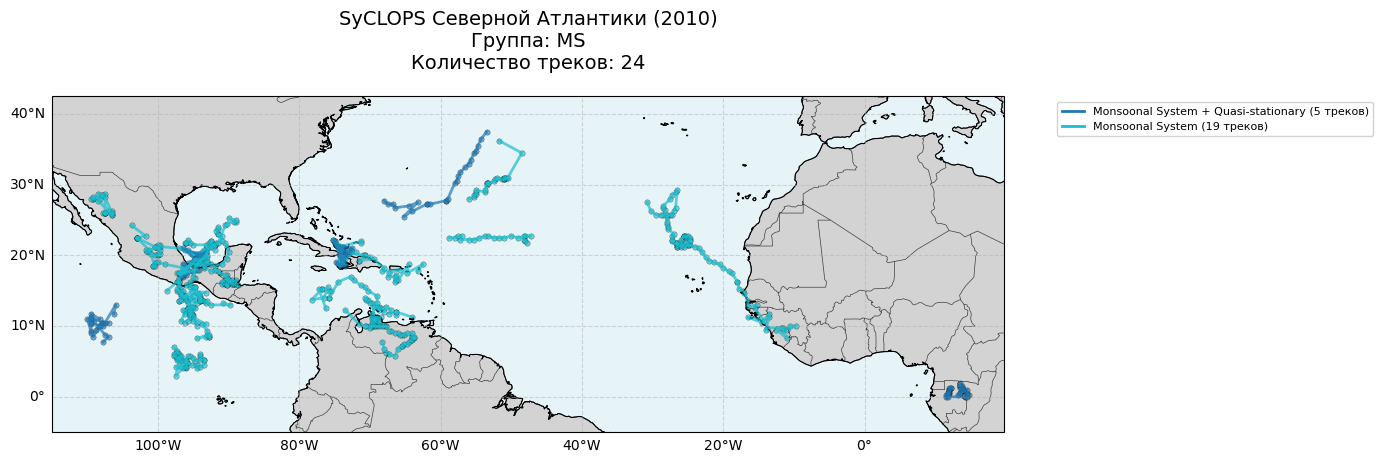

Сохранено: north_atlantic_2010_group_new_MS.png
  Включает типы: Track_MS_QS, Track_MS

Создание карты для группы: PTLC


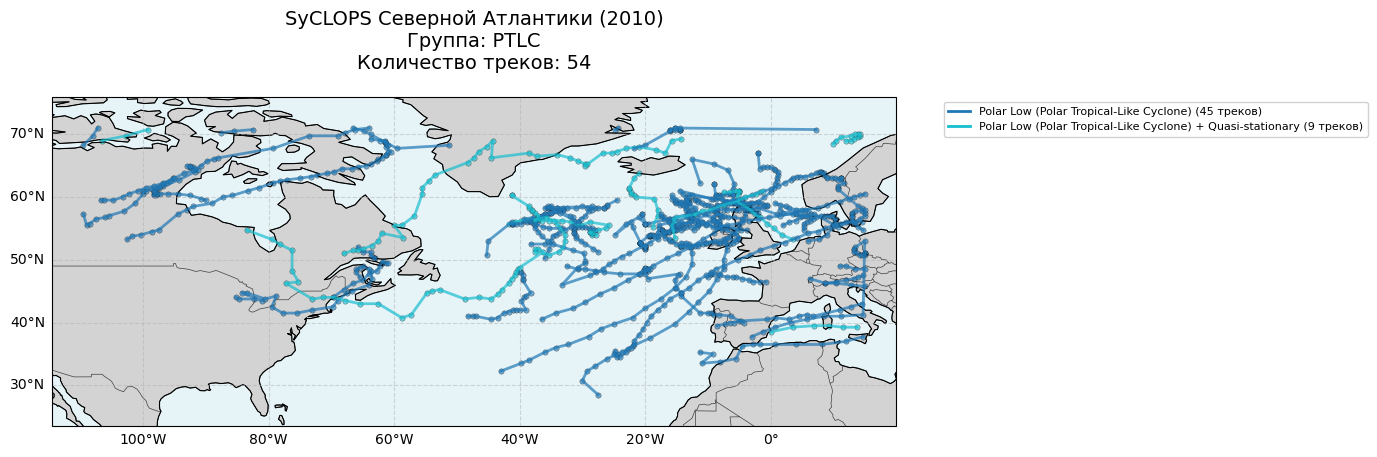

Сохранено: north_atlantic_2010_group_new_PTLC.png
  Включает типы: Track_PL(PTLC), Track_PL(PTLC)_QS

Создание карты для группы: STLC


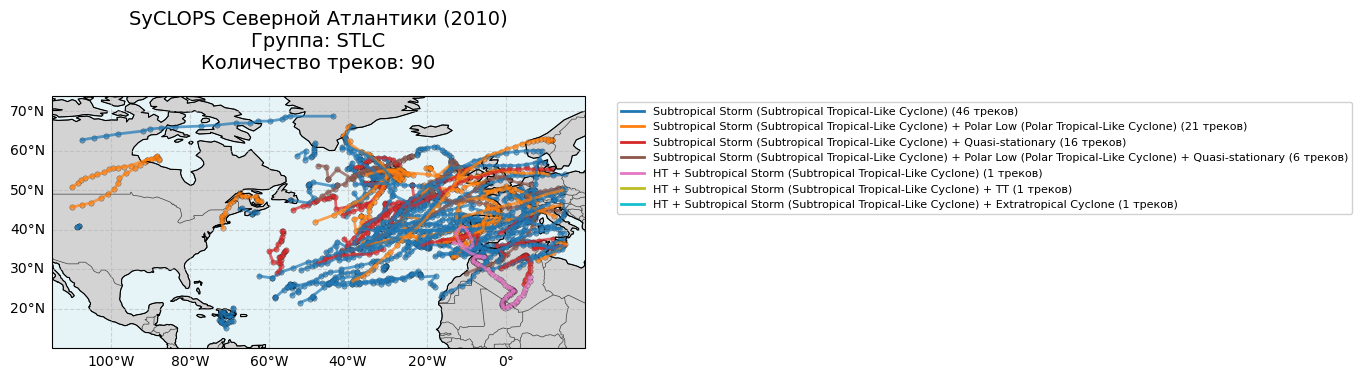

Сохранено: north_atlantic_2010_group_new_STLC.png
  Включает типы: Track_SS(STLC), Track_SS(STLC)_PL(PTLC), Track_SS(STLC)_QS, Track_SS(STLC)_PL(PTLC)_QS, Track_HT_SS(STLC), Track_HT_SS(STLC)_TT, Track_HT_SS(STLC)_EXT

Создание карты для группы: TC


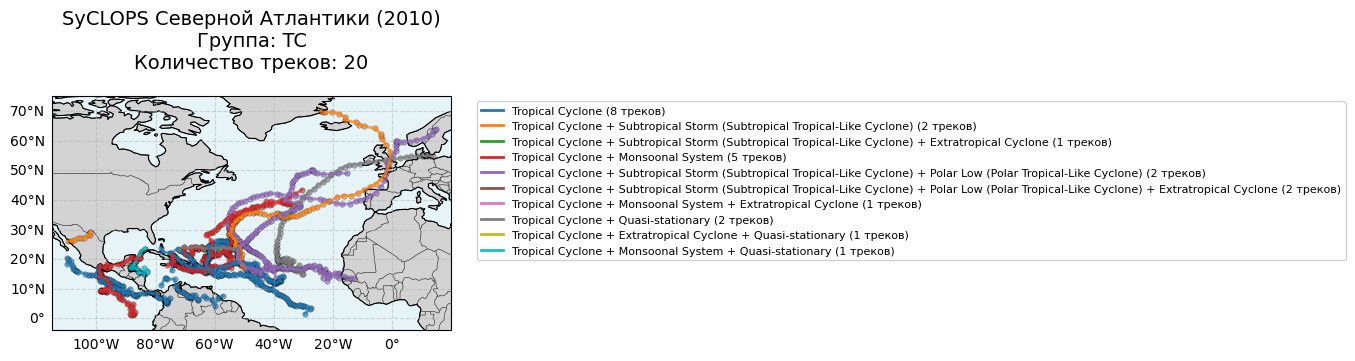

Сохранено: north_atlantic_2010_group_new_TC.png
  Включает типы: Track_TC, Track_TC_SS(STLC), Track_TC_SS(STLC)_EXT, Track_TC_MS, Track_TC_SS(STLC)_PL(PTLC), Track_TC_SS(STLC)_PL(PTLC)_EXT, Track_TC_MS_EXT, Track_TC_QS, Track_TC_EXT_QS, Track_TC_MS_QS

=== Статистика по группам ===
                      Количество треков  Количество узлов Типы в группе
SyCLoPS_primary_type                                                   
STLC                                 90              1917           NaN
PTLC                                 54              1082           NaN
MS                                   24               758           NaN
TC                                   20              1353           NaN


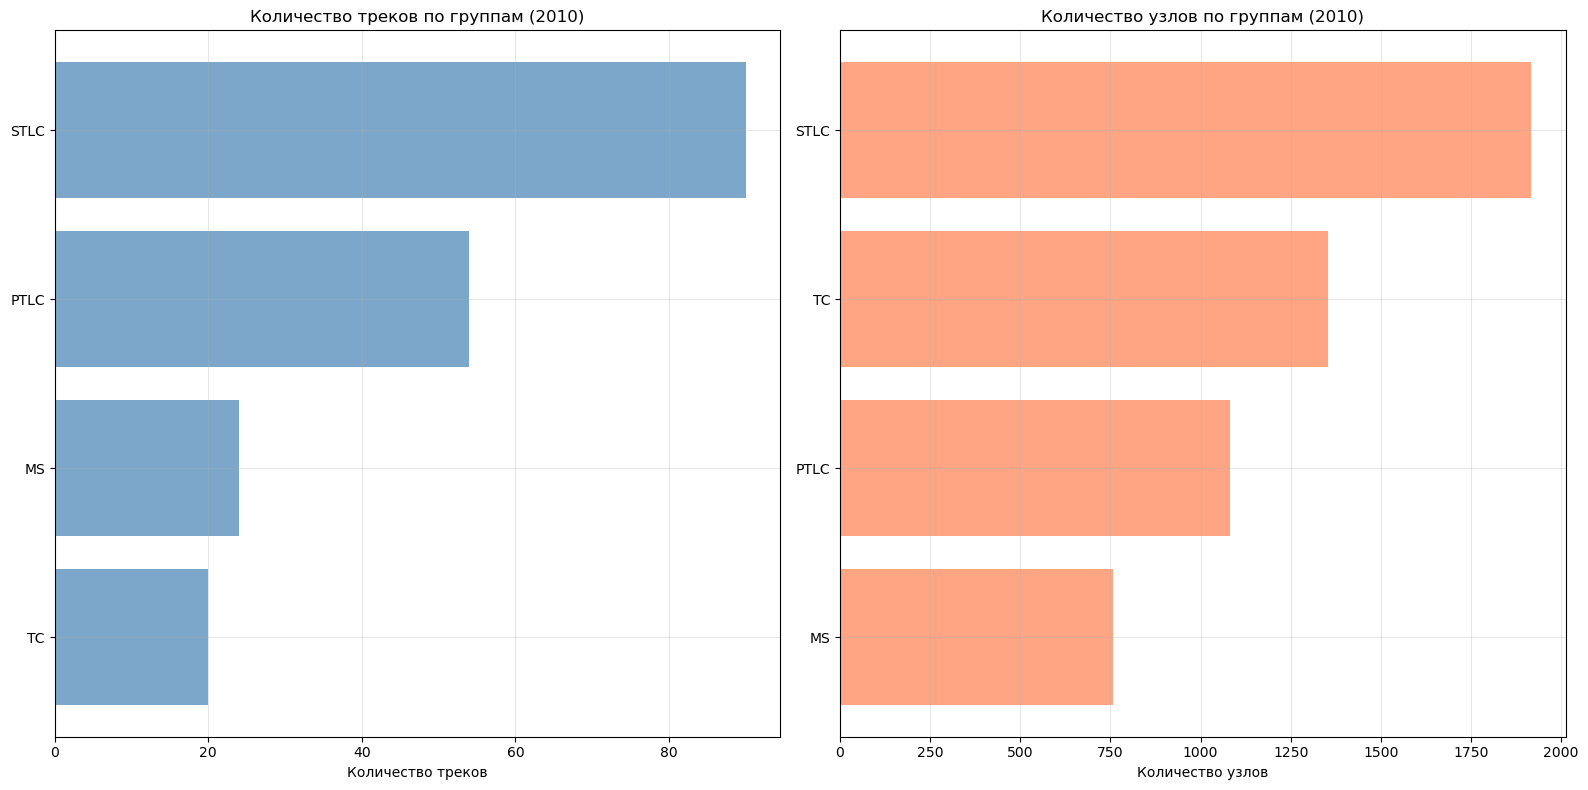


Графики сохранены:
1. north_atlantic_2010_group_*.png - карты по группам
2. track_groups_distribution_2010.png - статистика по группам


In [67]:

# Получение уникальных групп
unique_groups = df_atlantic_2010['SyCLoPS_primary_type'].dropna().unique()
print(f"Количество групп: {len(unique_groups)}")
print("Группы:", sorted(unique_groups))

# Создание отдельной карты для каждой группы
for group in sorted(unique_groups):
    print(f"\nСоздание карты для группы: {group}")
    
    # Фильтрация данных для текущей группы
    df_filtered = df_atlantic_2010[df_atlantic_2010['SyCLoPS_primary_type'] == group]
    
    # Получение уникальных треков (TID) для этой группы
    tc_tracks_filtered = df_filtered['TID'].unique()
    
    if len(tc_tracks_filtered) == 0:
        print(f"Нет данных для группы {group}")
        continue
    
    # Определение границ карты
    minlon = df_filtered['LON'].min() - 5
    maxlon = df_filtered['LON'].max() + 5
    minlat = df_filtered['LAT'].min() - 5
    maxlat = df_filtered['LAT'].max() + 5
    
    # Создание карты
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Настройка карты
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    
    # Добавление географических объектов
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
    
    # Настройка сетки
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    # Добавление названия с полным описанием
    plt.title(f'SyCLOPS Северной Атлантики (2010)\n'
              f'Группа: {group}\n'
              f'Количество треков: {len(tc_tracks_filtered)}', 
              fontsize=14, pad=20)
    
    # Определяем цвета для разных типов внутри группы
    # Используем разные цвета для разных Track_Info внутри группы
    track_types_in_group = df_filtered['Track_Info'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(track_types_in_group)))
    color_dict = {track_type: colors[i] for i, track_type in enumerate(track_types_in_group)}
    
    # Рисование треков
    for tid in tc_tracks_filtered:
        track_data = df_filtered[df_filtered['TID'] == tid].sort_values('ISOTIME')
        track_type = track_data['Track_Info'].iloc[0]
        color = color_dict.get(track_type, 'red')
        
        if len(track_data) > 1:
            # Линия трека
            ax.plot(track_data['LON'], track_data['LAT'], 
                    transform=ccrs.PlateCarree(),
                    linewidth=2.0, alpha=0.7,
                    color=color)
            
            # Точки
            ax.scatter(track_data['LON'], track_data['LAT'],
                      c=[color], s=15, alpha=0.6, 
                      transform=ccrs.PlateCarree(),
                      edgecolors='black', linewidth=0.3)
    
    # Добавляем легенду
    legend_elements = []
    for track_type in track_types_in_group:
        full_name = get_full_track_name(track_type)
        count = df_filtered[df_filtered['Track_Info'] == track_type]['TID'].nunique()
        color = color_dict[track_type]
        legend_elements.append(plt.Line2D([0], [0], color=color, lw=2, 
                                         label=f'{full_name} ({count} треков)'))
    
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper left', fontsize=8, 
                 bbox_to_anchor=(1.05, 1), framealpha=0.9)
    
    plt.tight_layout()
    
    # Сохранение карты с безопасным именем файла
    safe_filename = group.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    filename = f'north_atlantic_2010_group_new_{safe_filename}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Сохранено: {filename}")
    print(f"  Включает типы: {', '.join(track_types_in_group)}")

# Статистика по группам
print("\n=== Статистика по группам ===")
group_stats = df_atlantic_2010.groupby('SyCLoPS_primary_type').agg({
    'TID': 'nunique',
    'LON': 'count'
}).rename(columns={'TID': 'Количество треков', 'LON': 'Количество узлов'})

# Добавляем список типов в каждой группе
group_types = df_atlantic_2010.groupby('Track_Group')['Track_Info'].apply(lambda x: list(x.unique()))
group_stats['Типы в группе'] = group_types.apply(lambda x: ', '.join(x))
print(group_stats.sort_values('Количество треков', ascending=False))

# Визуализация распределения по группам
fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Количество треков по группам
track_counts_group = df_atlantic_2010.groupby('SyCLoPS_primary_type')['TID'].nunique().sort_values(ascending=True)
ax1.barh(track_counts_group.index, track_counts_group.values, color='steelblue', alpha=0.7)
ax1.set_title('Количество треков по группам (2010)', fontsize=12)
ax1.set_xlabel('Количество треков')
ax1.grid(True, alpha=0.3)

# Количество узлов по группам
node_counts_group = df_atlantic_2010.groupby('SyCLoPS_primary_type').size().sort_values(ascending=True)
ax2.barh(node_counts_group.index, node_counts_group.values, color='coral', alpha=0.7)
ax2.set_title('Количество узлов по группам (2010)', fontsize=12)
ax2.set_xlabel('Количество узлов')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('track_groups_distribution_2010_new.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nГрафики сохранены:")
print("1. north_atlantic_2010_group_*.png - карты по группам")
print("2. track_groups_distribution_2010.png - статистика по группам")

In [23]:
df_track = df_atlantic_2010[(df_atlantic_2010['Track_Info'] == 'Track')]

df_track[['TID', 'LON', 'LAT', 'ISOTIME', 'Short_Label',
       'Adjusted_Label', 'Tropical_Flag', 'Transition_Zone', 'Track_Info',
       ]]

,TID,LON,LAT,ISOTIME,Short_Label,Adjusted_Label,Tropical_Flag,Transition_Zone,Track_Info
10436662,517516,-28.75,46.00,2010-01-01 00:00:00,DSE,DSE,0.0,0.0,Track
10436663,517516,-30.25,46.50,2010-01-01 03:00:00,EX,EX,0.0,0.0,Track
10436664,517516,-32.00,46.50,2010-01-01 06:00:00,PL(PTLC),PL(PTLC),0.0,0.0,Track
10436665,517516,-33.75,46.25,2010-01-01 09:00:00,EX,EX,0.0,0.0,Track
10436666,517516,-35.00,45.75,2010-01-01 12:00:00,EX,EX,0.0,0.0,Track
...,...,...,...,...,...,...,...,...,...
10586474,524855,-37.25,39.00,2010-12-31 09:00:00,SS(STLC),SS(STLC),0.0,0.0,Track
10586475,524855,-35.75,39.00,2010-12-31 12:00:00,SC,SC,0.0,0.0,Track
10586476,524855,-35.75,38.00,2010-12-31 15:00:00,SC,SC,0.0,0.0,Track
10586477,524855,-34.50,37.75,2010-12-31 18:00:00,SC,SC,0.0,0.0,Track


=== Распределение Track_Info ===
Track_Info
Track                         690794
Track_QS                      181986
Track_SS(STLC)                 56181
Track_PL(PTLC)                 35752
Track_TC                       31004
Track_MS                       30134
Track_SS(STLC)_PL(PTLC)        26191
Track_TC_MS                    24892
Track_SS(STLC)_QS              14479
Track_TC_SS(STLC)              13469
Track_PL(PTLC)_QS               9443
Track_TC_MS_QS                  8228
Track_TC_QS                     7947
Track_MS_QS                     7293
Track_SS(STLC)_PL(PTLC)_QS      6778
Track_TC_MS_SS(STLC)            4432
Track_TC_SS(STLC)_QS            4057
Track_TC_SS(STLC)_PL(PTLC)      2051
Track_TC_MS_SS(STLC)_QS         1463
Track_MS_SS(STLC)               1040
Name: count, dtype: int64

=== Распределение Short_Label ===
Short_Label
EX          463015
DSE         114632
THL         101844
HATHL        98831
TC           50525
TLO          46367
DST          44881
HAL       

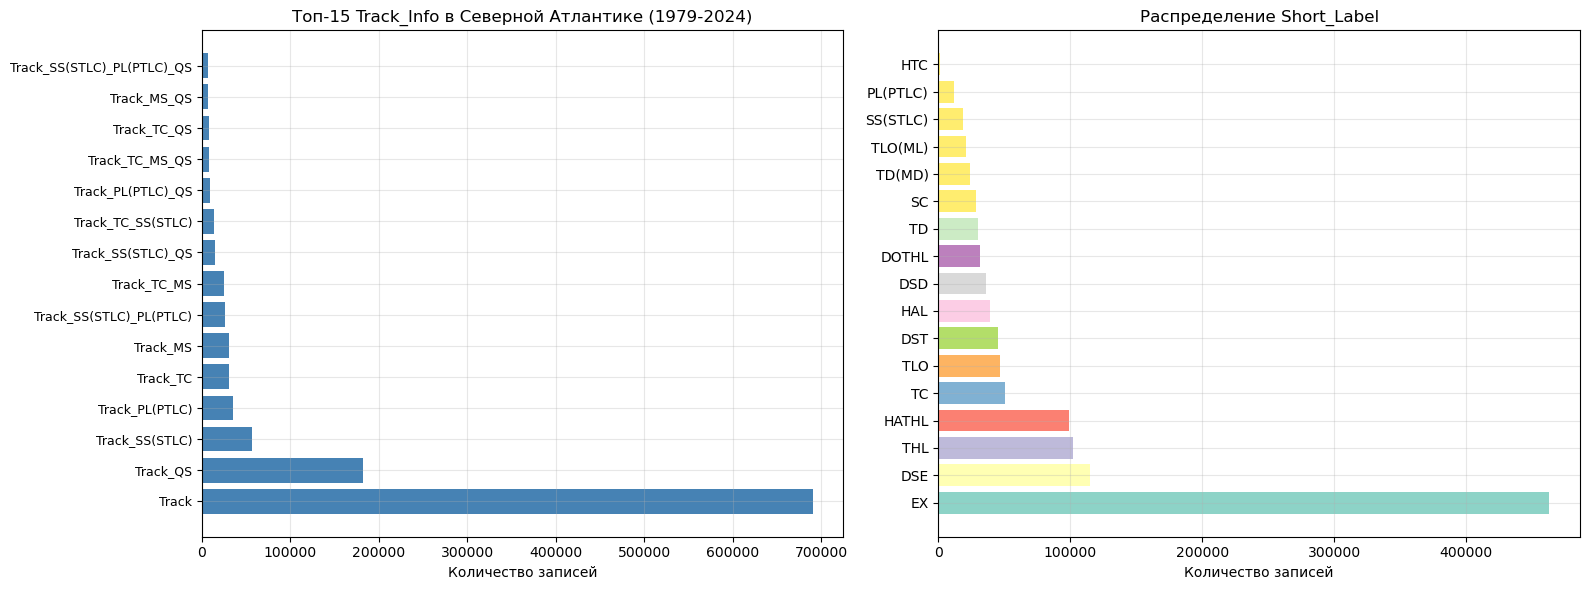


=== Сводка Track_Info по Short_Label ===
Short_Label                    DOTHL    DSD    DSE    DST      EX    HAL  \
Track_Info                                                                 
Track                          24327  27373  79789  29798  289386  30501   
Track_HT                           0      0      0      0       5      0   
Track_HT_MS_SS(STLC)               0      0     22      2      17      0   
Track_HT_MS_SS(STLC)_EXT           0      0      0      0       1      0   
Track_HT_MS_SS(STLC)_TT            0      0      0      0       0      0   
...                              ...    ...    ...    ...     ...    ...   
Track_TC_SS(STLC)_PL(PTLC)_QS      0      0     14     20      94      0   
Track_TC_SS(STLC)_QS              11      2     81     73     577      0   
Track_TC_SS(STLC)_TT               0      0      0      0       0      0   
Track_TC_SS(STLC)_TT_QS            0      0      0      0       0      0   
Track_TC_TT                        0      0   

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные уже отфильтрованы по региону и времени в df_atlantic

# 1. Распределение Track_Info (топ-20)
print("=== Распределение Track_Info ===")
track_counts = df_atlantic['Track_Info'].value_counts()
print(track_counts.head(20))

# 2. Распределение Short_Label
print("\n=== Распределение Short_Label ===")
label_counts = df_atlantic['Short_Label'].value_counts()
print(label_counts)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Track_Info (топ-15)
top_tracks = track_counts.head(15)
ax1.barh(range(len(top_tracks)), top_tracks.values, color='steelblue')
ax1.set_yticks(range(len(top_tracks)))
ax1.set_yticklabels(top_tracks.index, fontsize=9)
ax1.set_xlabel('Количество записей')
ax1.set_title('Топ-15 Track_Info в Северной Атлантике (1979-2024)')
ax1.grid(True, alpha=0.3)

# Short_Label
colors = plt.cm.Set3(range(len(label_counts)))
ax2.barh(range(len(label_counts)), label_counts.values, color=colors)
ax2.set_yticks(range(len(label_counts)))
ax2.set_yticklabels(label_counts.index, fontsize=10)
ax2.set_xlabel('Количество записей')
ax2.set_title('Распределение Short_Label')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Сводная таблица: Track_Info vs Short_Label
print("\n=== Сводка Track_Info по Short_Label ===")
cross_tab = pd.crosstab(df_atlantic['Track_Info'], df_atlantic['Short_Label'])
print(cross_tab)

# 4. Только Track_TC
print("\n=== Track_Info == 'Track_TC' ===")
df_tc_track = df_atlantic[df_atlantic['Track_Info'] == 'Track_TC']
print(f"Количество: {len(df_tc_track)}")
print("\nРаспределение Short_Label для Track_TC:")
print(df_tc_track['Short_Label'].value_counts())

In [9]:
# ВЫБОР ТРОПИЧЕСКИХ ЦИКЛОНОВ
print("Выбор тропических циклонов...")
df_tc = df_atlantic[df_atlantic['Track_Info'] == 'Track_TC']
df_tc = dfc[dfc['Track_Info'] == 'Track_TC']



print(f"Записей тропических циклонов (TC): {len(df_tc['TID'].unique())}")
print(f"Записей тропических циклонов (TC): {df_tc['Track_Info'].unique()}")

df_tc[['TID', 'LON', 'LAT', 'ISOTIME', 'Short_Label',
       'Adjusted_Label', 'Tropical_Flag', 'Transition_Zone', 'Track_Info',
       ]]

Выбор тропических циклонов...
Записей тропических циклонов (TC): 2018
Записей тропических циклонов (TC): ['Track_TC']


,TID,LON,LAT,ISOTIME,Short_Label,Adjusted_Label,Tropical_Flag,Transition_Zone,Track_Info
313,19,-71.50,0.50,1940-01-01 00:00:00,TLO(ML),TLO(ML),1.0,0.0,Track_TC
314,19,-69.75,2.25,1940-01-01 12:00:00,TLO(ML),TLO(ML),1.0,0.0,Track_TC
315,19,-69.75,2.00,1940-01-01 15:00:00,TLO(ML),TLO(ML),1.0,0.0,Track_TC
316,19,-69.50,2.25,1940-01-01 18:00:00,TLO(ML),TLO(ML),1.0,0.0,Track_TC
317,19,-69.75,2.00,1940-01-01 21:00:00,TLO,TLO,1.0,0.0,Track_TC
...,...,...,...,...,...,...,...,...,...
12679772,627736,-72.25,8.50,2024-12-26 00:00:00,DST,DST,1.0,0.0,Track_TC
12679773,627736,-72.75,8.50,2024-12-26 03:00:00,DST,DST,1.0,0.0,Track_TC
12679774,627736,-73.25,8.50,2024-12-26 06:00:00,DST,DST,1.0,0.0,Track_TC
12679775,627736,-74.00,8.50,2024-12-26 09:00:00,DST,DST,1.0,0.0,Track_TC


In [37]:
df_tc = dfc[dfc['Track_Info'] == 'Track_TC']
print(df_tc[['TID', 'LON', 'LAT', 'ISOTIME', 'MSLP', 'WS']])

             TID    LON   LAT             ISOTIME      MSLP        WS
313           19 -71.50  0.50 1940-01-01 00:00:00  101194.2  10.61969
314           19 -69.75  2.25 1940-01-01 12:00:00  101002.1  11.04256
315           19 -69.75  2.00 1940-01-01 15:00:00  101098.5  11.45651
316           19 -69.50  2.25 1940-01-01 18:00:00  101020.7  11.47295
317           19 -69.75  2.00 1940-01-01 21:00:00  100912.2  11.84471
...          ...    ...   ...                 ...       ...       ...
12679772  627736 -72.25  8.50 2024-12-26 00:00:00  101069.7  12.51521
12679773  627736 -72.75  8.50 2024-12-26 03:00:00  101278.0  12.11220
12679774  627736 -73.25  8.50 2024-12-26 06:00:00  101073.9  11.20185
12679775  627736 -74.00  8.50 2024-12-26 09:00:00  100902.9  10.97999
12679776  627736 -75.75  7.50 2024-12-26 18:00:00  101149.3  10.75302

[140705 rows x 6 columns]


In [28]:
df_tc=dfc[dfc.Short_Label.str.contains('TD')]
tctid=pd.unique(df_tc.TID)
df_tc

,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,Transition_Zone,Track_Info,LPSAREA,i,j,distance,direction
322,19,-69.00,2.25,1940-01-02 12:00:00,100911.4,13.37531,-4.942871,...,0.0,Track_TC,152702,444,351,27.798732,180.000000
332,19,-68.50,3.25,1940-01-03 21:00:00,100715.6,12.42810,-3.997559,...,0.0,Track_TC,366106,446,347,55.508044,270.014173
337,19,-68.00,3.50,1940-01-04 12:00:00,100694.5,12.81311,0.670410,...,0.0,Track_TC,266833,448,346,27.746881,89.992369
341,19,-68.00,4.00,1940-01-05 00:00:00,100652.4,12.39902,-0.470215,...,0.0,Track_TC,224986,448,344,27.798732,0.000000
342,19,-68.00,4.00,1940-01-05 03:00:00,100675.5,12.57633,-0.470215,...,0.0,Track_TC,230229,448,344,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12684090,627961,-71.25,-12.00,2024-12-31 06:00:00,100270.8,15.03597,-0.220215,...,0.0,Track,420344,435,408,27.191262,90.025989
12684091,627961,-71.00,-12.00,2024-12-31 09:00:00,100097.7,15.26137,2.287598,...,0.0,Track,407941,436,408,27.191262,90.025989
12684092,627961,-70.75,-12.75,2024-12-31 12:00:00,100302.6,14.18789,-8.513184,...,0.0,Track,382925,437,411,87.705135,161.991982
12684692,627995,-16.75,-13.00,2024-12-29 18:00:00,100804.1,10.18985,-1.595215,...,0.0,Track_MS,0,653,412,85.920660,108.960391


In [17]:
df_tc_2010 = df_tc[
    (df_tc['ISOTIME'].dt.year == 2010)]
np.min(df_tc.MSLP)

np.float64(89991.06)

In [31]:
tcsspl_trackid = pd.unique(dfc[(dfc.Track_Info.str.contains('TC')) | (dfc.Track_Info.str.contains('SS')) | (dfc.Track_Info.str.contains('PL'))].TID)
df_tc=dfc[dfc.TID.isin(tcsspl_trackid)]
df_tc

,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,Transition_Zone,Track_Info,LPSAREA,i,j,distance,direction
72,4,-135.00,54.75,1940-01-01 00:00:00,100302.40,6.934227,1613.530000,...,0.0,Track_PL(PTLC),541208,180,141,NaN,NaN
73,4,-134.00,55.25,1940-01-01 03:00:00,100301.80,6.315382,1320.014000,...,0.0,Track_PL(PTLC),451166,184,139,84.608267,48.511803
74,4,-131.50,55.75,1940-01-01 06:00:00,100301.00,5.876720,916.533700,...,0.0,Track_PL(PTLC),547177,194,137,166.969857,69.524389
75,4,-130.25,56.25,1940-01-01 09:00:00,100238.60,7.032510,1472.288000,...,0.0,Track_PL(PTLC),631171,199,135,95.559844,53.906230
76,4,-128.00,56.50,1940-01-01 12:00:00,100283.90,6.570168,1663.604000,...,0.0,Track_PL(PTLC),438268,208,134,141.297664,77.718869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12684995,628017,8.25,41.75,2024-12-31 09:00:00,98137.94,26.965960,1.881348,...,0.0,Track_SS(STLC)_PL(PTLC),1591329,753,193,195.447383,72.730430
12684996,628017,9.75,42.75,2024-12-31 12:00:00,98199.81,24.381820,0.271973,...,0.0,Track_SS(STLC)_PL(PTLC),1734546,759,189,166.149403,47.490358
12684997,628017,11.00,43.50,2024-12-31 15:00:00,98066.06,23.533540,-0.981934,...,0.0,Track_SS(STLC)_PL(PTLC),1886487,764,186,131.322461,50.151424
12684998,628017,11.75,44.00,2024-12-31 18:00:00,98096.75,23.149840,0.549316,...,0.0,Track_SS(STLC)_PL(PTLC),2204847,767,184,81.976303,47.037390


In [13]:
import pandas as pd
import numpy as np
from datetime import datetime
import os


# df_tc = dfc[dfc['Track_Info'] == 'Track_TC']

df_tc=dfc[dfc.Track_Info.str.contains('TC')]





output_folder = f'{path_dir_data}/SyCLoPS/all_TC_tracks_TE_format/'
os.makedirs(output_folder, exist_ok=True)

# Убедимся, что ISOTIME в формате datetime
df_tc['ISOTIME'] = pd.to_datetime(df_tc['ISOTIME'])

# Создаем колонки для группировки
df_tc['year'] = df_tc['ISOTIME'].dt.year
df_tc['month'] = df_tc['ISOTIME'].dt.month
df_tc['day'] = df_tc['ISOTIME'].dt.day
df_tc['hour'] = df_tc['ISOTIME'].dt.hour

# Функция для сохранения в формате Tempest Extremes (для одного года)
def save_tempest_format_by_year(df, year, output_dir='.'):
    """
    Сохраняет данные в формате Tempest Extremes для конкретного года
    Все месяцы сохраняются в один файл
    """
    # Фильтруем данные по году
    mask = (df['year'] == year)
    df_filtered = df[mask].copy()
    
    if len(df_filtered) == 0:
        return  # Нет данных - ничего не сохраняем
    
    # Сортируем по TID и ISOTIME для правильного порядка
    df_filtered = df_filtered.sort_values(['TID', 'ISOTIME'])
    
    # Имя выходного файла (только год)
    filename = f"{output_dir}/TC_tracks_{year}.txt"
    
    with open(filename, 'w') as f:
        # Группируем по TID (идентификатору трека)
        for tid, group in df_filtered.groupby('TID'):
            # Сортируем по времени внутри трека
            group = group.sort_values('ISOTIME')
            
            # Записываем заголовок трека: start количество_точек год месяц день час
            first_row = group.iloc[0]
            num_points = len(group)
            f.write(f"start\t{num_points}\t{first_row['year']}\t{first_row['month']}\t{first_row['day']}\t{first_row['hour']}\n")
            
            # Записываем точки трека
            for _, row in group.iterrows():
                # Индекс долготы и широты для сетки ERA5 (0.25 градуса)
                # Для долготы: (lon + 180) / 0.25, так как долгота от -180 до 180
                # Для широты: (lat + 90) / 0.25, так как широта от -90 до 90
                lon_idx = int(round((row['LON'] + 180) / 0.25))
                lat_idx = int(round((row['LAT'] + 90) / 0.25))
                
                # Записываем: индекс_долготы индекс_широты долгота широта MSLP WS год месяц день час
                f.write(f"\t{lon_idx}\t{lat_idx}\t{row['LON']:.6f}\t{row['LAT']:.6f}\t{row['MSLP']:.6e}\t{row['WS']:.6e}\t{row['year']}\t{row['month']}\t{row['day']}\t{row['hour']}\n")
    
    print(f"Сохранен файл: {filename} ({len(df_filtered)} записей, {df_filtered['TID'].nunique()} треков)")

# Получаем все уникальные года
years = df_tc['year'].unique()
years.sort()

# Сохраняем каждый год в отдельный файл (все месяцы вместе)
for year in years:
    save_tempest_format_by_year(df_tc, year, output_folder)

print("Готово!")

Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1940.txt (5299 записей, 52 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1941.txt (7153 записей, 69 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1942.txt (6176 записей, 70 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1943.txt (3845 записей, 44 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1944.txt (5256 записей, 63 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1945.txt (4988 записей, 57 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC_tracks_TE_format//TC_tracks_1946.txt (5282 записей, 58 треков)
Сохранен файл: /storage/thalassa/users/vkoshkina/data//SyCLoPS/all_TC

Количество уникальных TC треков: 2018
Создание карты...


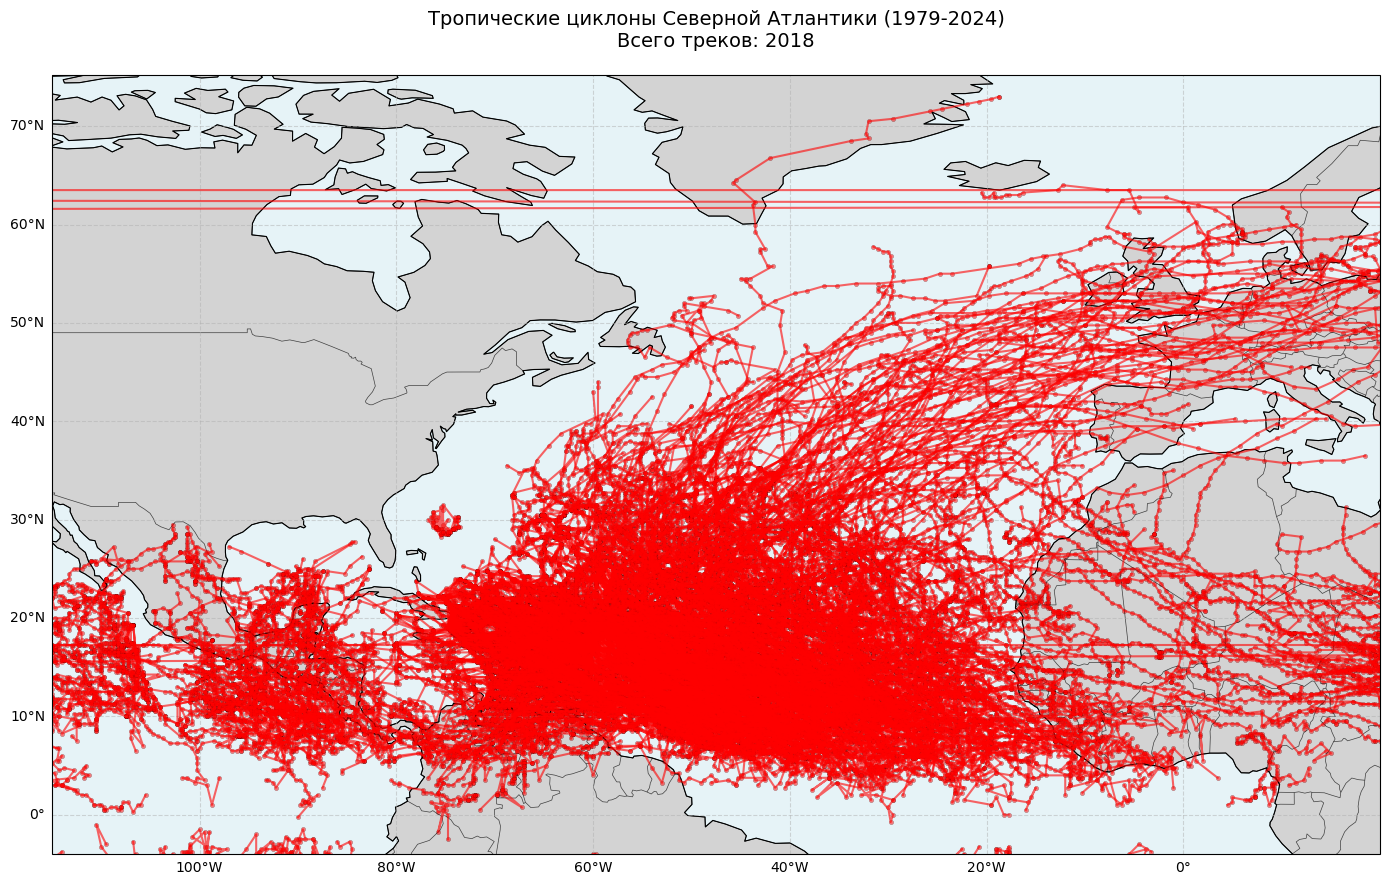


=== Статистика по тропическим циклонам ===
Общее количество треков: 2018
Общее количество узлов: 140705

Распределение по типам (по трекам):
TC         1432
TD          351
TLO         160
DST          36
EX           26
DSE           6
TD(MD)        3
HTC           1
TLO(ML)       1
SC            1
THL           1
Name: count, dtype: int64

Годы с наибольшим количеством треков:
Year
2022    37
2018    36
2019    36
1956    35
2015    34
2020    33
2017    33
1993    32
1994    32
2000    32
Name: TID, dtype: int64

Минимальное давление по трекам (мин): 92036.1 Па
Минимальное давление по трекам (макс): 101106.5 Па
Минимальное давление по трекам (среднее): 98971.8 Па

Средняя длина трека (в узлах): 69.7
Максимальная длина трека: 257


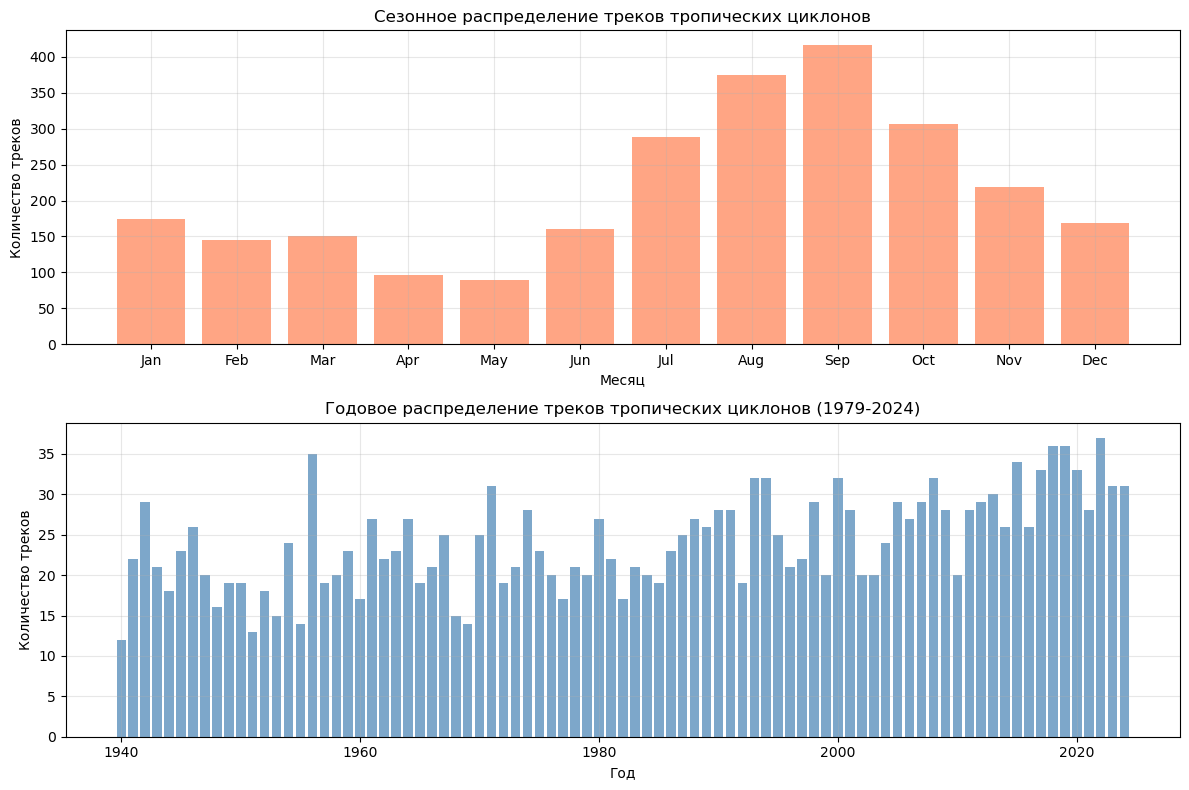


Графики сохранены в файлы:
1. north_atlantic_tropical_cyclones_1979_2024.png - карта треков
2. tc_statistics_north_atlantic.png - статистика

=== Топ-10 самых сильных циклонов (по минимальному давлению) ===
            MSLP    LAT     LON             ISOTIME
TID                                                
267700  92036.06   6.75  -34.50 1975-11-16 00:00:00
157484  92080.88 -10.50  -47.50 1961-01-21 03:00:00
311276  92388.38  11.75  -34.50 1981-09-23 12:00:00
384719  93137.38 -11.25    0.50 1991-12-03 06:00:00
282524  93219.38   9.50  -23.25 1977-11-04 18:00:00
626746  93234.38  10.00  -32.00 2024-10-23 06:00:00
252060  93379.56  10.75  -44.25 1973-10-01 00:00:00
175673  93454.19  11.50  -24.25 1963-07-06 06:00:00
353813  93486.25  10.50  -28.50 1987-08-20 21:00:00
485596  93561.06  22.50  104.50 2005-08-23 09:00:00

=== Распределение треков по длительности ===
1-5           0
6-10          0
11-20        44
21-50       555
51-100     1113
101-200     302
201+          4
Name: coun

In [38]:
# Получение списка уникальных треков TC
tc_tracks = df_tc['TID'].unique()
print(f"Количество уникальных TC треков: {len(tc_tracks)}")

# Визуализация треков
print("Создание карты...")
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Настройка карты
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

# Добавление географических объектов
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)

# Настройка сетки
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Добавление названия
plt.title(f'Тропические циклоны Северной Атлантики (1979-2024)\n'
          f'Всего треков: {len(tc_tracks)}', 
          fontsize=14, pad=20)

# Рисование треков
for tid in tc_tracks:
    track_data = df_tc[df_tc['TID'] == tid].sort_values('ISOTIME')
    
    if len(track_data) > 1:
        # Линия трека
        ax.plot(track_data['LON'], track_data['LAT'], 
                transform=ccrs.PlateCarree(),
                linewidth=1.5, alpha=0.6,
                color='red')
        
        # Точки
        ax.scatter(track_data['LON'], track_data['LAT'],
                  c='red', s=10, alpha=0.5, 
                  transform=ccrs.PlateCarree(),
                  edgecolors='black', linewidth=0.2)

plt.tight_layout()
plt.savefig('north_atlantic_tropical_cyclones_1979_2024.png', dpi=300, bbox_inches='tight')
plt.show()

# Статистика по трекам (а не по узлам)
print("\n=== Статистика по тропическим циклонам ===")
print(f"Общее количество треков: {len(tc_tracks)}")
print(f"Общее количество узлов: {len(df_tc)}")

# Распределение по типам (по трекам)
print("\nРаспределение по типам (по трекам):")
# Для каждого трека определяем основной тип
track_types = []
for tid in tc_tracks:
    track_data = df_tc[df_tc['TID'] == tid]
    main_type = track_data['Short_Label'].value_counts().index[0]
    track_types.append(main_type)
print(pd.Series(track_types).value_counts())

# Годы с наибольшим количеством треков
df_tc['Year'] = pd.to_datetime(df_tc['ISOTIME']).dt.year
yearly_tracks = df_tc.groupby('Year')['TID'].nunique()  # уникальные TID по годам
print(f"\nГоды с наибольшим количеством треков:")
print(yearly_tracks.sort_values(ascending=False).head(10))

# Средние характеристики по трекам
track_min_mslp = df_tc.groupby('TID')['MSLP'].min()
print(f"\nМинимальное давление по трекам (мин): {track_min_mslp.min():.1f} Па")
print(f"Минимальное давление по трекам (макс): {track_min_mslp.max():.1f} Па")
print(f"Минимальное давление по трекам (среднее): {track_min_mslp.mean():.1f} Па")

# Статистика по длине треков
track_lengths = df_tc.groupby('TID').size()
print(f"\nСредняя длина трека (в узлах): {track_lengths.mean():.1f}")
print(f"Максимальная длина трека: {track_lengths.max()}")

# Визуализация временного ряда (по трекам)
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Количество треков по месяцам
df_tc['Month'] = pd.to_datetime(df_tc['ISOTIME']).dt.month
monthly_tracks = df_tc.groupby('Month')['TID'].nunique()
ax1.bar(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
        monthly_tracks.values, color='coral', alpha=0.7)
ax1.set_title('Сезонное распределение треков тропических циклонов', fontsize=12)
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество треков')
ax1.grid(True, alpha=0.3)

# Годовое распределение треков
ax2.bar(yearly_tracks.index, yearly_tracks.values, color='steelblue', alpha=0.7)
ax2.set_title('Годовое распределение треков тропических циклонов (1979-2024)', fontsize=12)
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество треков')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tc_statistics_north_atlantic.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nГрафики сохранены в файлы:")
print("1. north_atlantic_tropical_cyclones_1979_2024.png - карта треков")
print("2. tc_statistics_north_atlantic.png - статистика")

# Топ-10 самых сильных циклонов (по минимальному давлению)
print("\n=== Топ-10 самых сильных циклонов (по минимальному давлению) ===")
strongest = df_tc.groupby('TID').agg({
    'MSLP': 'min',
    'LAT': 'first',
    'LON': 'first',
    'ISOTIME': 'first'
}).sort_values('MSLP').head(10)
print(strongest)

# Дополнительно: распределение по длительности
print("\n=== Распределение треков по длительности ===")
duration_bins = [0, 5, 10, 20, 50, 100, 200, 500]
duration_labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201+']
track_lengths_cut = pd.cut(track_lengths, bins=duration_bins, labels=duration_labels)
print(track_lengths_cut.value_counts().sort_index())

## 3. Общая информация о данных

Посмотрим на структуру каталога, типы данных и основные статистики.

In [20]:
# Первые несколько строк
print("\nПервые 5 записей каталога:")
df.head()


Первые 5 записей каталога:


,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,...,Transition_Zone,Track_Info,LPSAREA,i,j,distance,direction
0,0,38.00,74.75,1940-01-01 00:00:00,99764.19,18.17691,-0.813965,...,0.0,Track,0,152,61,NaN,NaN
1,0,38.75,75.25,1940-01-01 03:00:00,99729.75,19.37490,3.150879,...,0.0,Track,0,155,59,59.639223,20.855746
2,0,37.00,75.50,1940-01-01 06:00:00,99653.75,19.31102,-8.552246,...,0.0,Track,0,148,58,56.448521,300.345463
3,0,35.00,75.50,1940-01-01 09:00:00,99589.88,19.72554,5.807129,...,0.0,Track,0,140,58,55.679323,270.968154
4,0,33.25,75.25,1940-01-01 12:00:00,99357.12,19.69311,6.877441,...,0.0,Track,0,133,59,56.448521,241.347848


In [31]:
df.columns

Index(['TID', 'LON', 'LAT', 'ISOTIME', 'MSLP', 'WS', 'ZS', 'Short_Label',
       'Adjusted_Label', 'Tropical_Flag', 'Transition_Zone', 'Track_Info',
       'LPSAREA', 'i', 'j', 'distance', 'direction'],
      dtype='object')

In [27]:
# Информация о колонках и типах данных
print("\nИнформация о колонках:")
df.info()

df['Short_Label'].unique()


Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12685049 entries, 0 to 12685048
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   TID              int64         
 1   LON              float64       
 2   LAT              float64       
 3   ISOTIME          datetime64[ns]
 4   MSLP             float64       
 5   WS               float64       
 6   ZS               float64       
 7   Short_Label      object        
 8   Adjusted_Label   object        
 9   Tropical_Flag    float64       
 10  Transition_Zone  float64       
 11  Track_Info       object        
 12  LPSAREA          int64         
 13  i                int64         
 14  j                int64         
 15  distance         float64       
 16  direction        float64       
dtypes: datetime64[ns](1), float64(9), int64(4), object(3)
memory usage: 1.6+ GB


array(['EX', 'PL(PTLC)', 'HATHL', 'HAL', 'DSE', 'SC', 'SS(STLC)', 'DSD',
       'THL', 'TLO(ML)', 'TLO', 'TD', 'TC', 'TD(MD)', 'DST', 'DOTHL',
       'HTC'], dtype=object)

In [5]:
# Основные статистики для числовых колонок
print("\nОсновные статистики для числовых колонок:")
df.describe()


Основные статистики для числовых колонок:


,TID,LON,LAT,ISOTIME,MSLP,WS,ZS,Tropical_Flag,Transition_Zone,LPSAREA,i,j,distance,direction
count,1.268505e+07,1.268505e+07,1.268505e+07,12685049,1.268505e+07,1.268505e+07,1.268505e+07,1.268505e+07,1.268505e+07,1.268505e+07,1.268505e+07,1.268505e+07,1.213804e+07,1.213804e+07
mean,3.149189e+05,1.715484e+02,4.683258e-01,1982-06-19 10:24:20.346207424,9.955575e+04,1.230255e+01,3.324697e+03,1.858939e-01,7.273303e-02,4.397723e+05,6.861934e+02,3.581267e+02,1.084735e+02,1.267681e+02
min,0.000000e+00,0.000000e+00,-8.950000e+01,1940-01-01 00:00:00,8.999106e+04,1.224494e+00,-1.260775e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.571560e+05,7.875000e+01,-4.975000e+01,1961-01-05 21:00:00,9.857106e+04,8.649706e+00,-9.702148e-01,0.000000e+00,0.000000e+00,0.000000e+00,3.150000e+02,1.750000e+02,3.824379e+01,5.461819e+01
50%,3.165530e+05,1.667500e+02,1.150000e+01,1982-06-23 03:00:00,1.000556e+05,1.189506e+01,3.576660e+00,0.000000e+00,0.000000e+00,1.046660e+05,6.670000e+02,3.140000e+02,8.364741e+01,1.066137e+02
75%,4.724900e+05,2.630000e+02,4.625000e+01,2003-11-15 00:00:00,1.007833e+05,1.551494e+01,2.506874e+03,0.000000e+00,0.000000e+00,6.268460e+05,1.052000e+03,5.590000e+02,1.502828e+02,1.800000e+02
max,6.280230e+05,3.597500e+02,9.000000e+01,2024-12-31 21:00:00,1.067449e+05,3.097844e+02,5.745817e+04,1.000000e+00,1.000000e+00,1.908881e+07,1.439000e+03,7.180000e+02,8.816315e+02,3.600000e+02
std,1.817588e+05,1.052332e+02,5.047699e+01,NaN,1.676901e+03,4.850292e+00,7.723936e+03,3.890210e-01,2.596978e-01,6.893302e+05,4.209329e+02,2.019080e+02,9.394941e+01,9.698429e+01


## 4. Базовый анализ и фильтрация

Руководство SyCLoPS описывает множество способов фильтрации. Воспроизведем ключевые из них и добавим визуализацию.

### 4.1. Обзор уникальных меток и их распределение

In [6]:
# Выбор основной колонки с метками. В руководстве рекомендуется использовать 'Adjusted_Label'
label_col = 'Adjusted_Label'

print(f"\nУникальные метки в колонке '{label_col}':")
print(df[label_col].unique())

print("\nРаспределение меток (топ-10):")
label_counts = df[label_col].value_counts()
print(label_counts.head(10))


Уникальные метки в колонке 'Adjusted_Label':
['EX' 'PL(PTLC)' 'HATHL' 'HAL' 'DSE' 'SC' 'SS(STLC)' 'DSD' 'THL' 'TLO(ML)'
 'TLO' 'TD' 'TC' 'TD(MD)' 'DST' 'DOTHL' 'HTC']

Распределение меток (топ-10):
Adjusted_Label
EX       6174039
THL      1336063
DSE       959830
HATHL     572518
HAL       494843
DOTHL     481816
SC        463673
DSD       452500
TLO       368171
DST       361772
Name: count, dtype: int64


/tmp/ipykernel_995435/2248464652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')


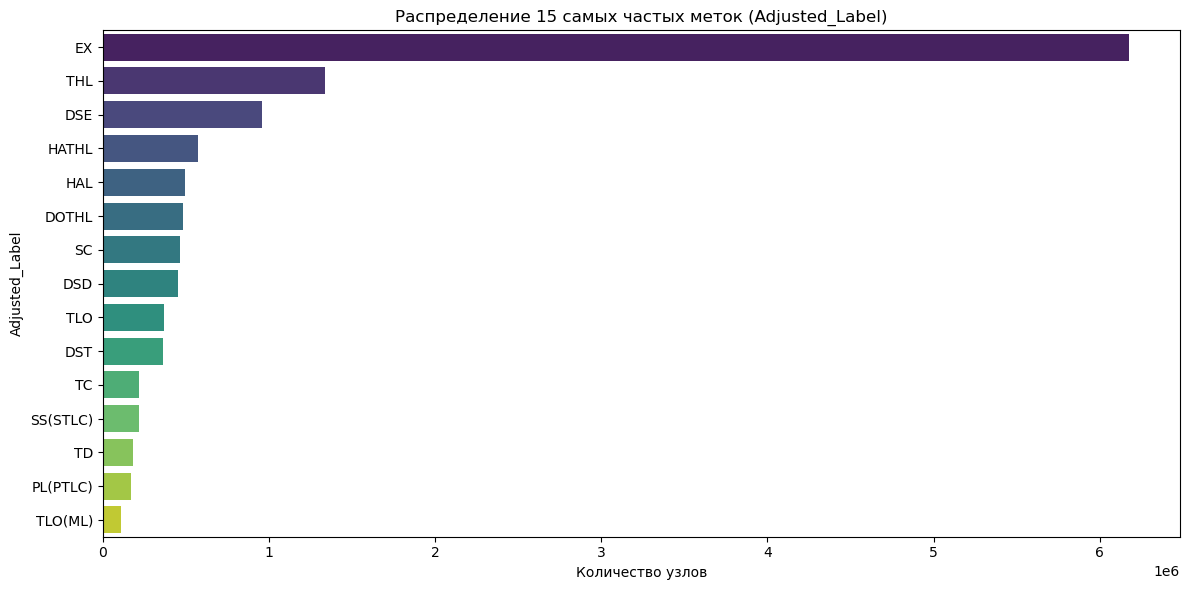

In [7]:
# Визуализация распределения основных типов
plt.figure(figsize=(12, 6))
top_labels = label_counts.head(15)
sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')
plt.title(f'Распределение 15 самых частых меток ({label_col})')
plt.xlabel('Количество узлов')
plt.tight_layout()
plt.show()

### 4.2. Выборка по конкретным типам (Примеры из руководства)

In [8]:
# Task 1: Выбрать один тип, например Thermal Low (THL)
df_thl = df[df[label_col] == 'THL']
print(f"\nЗадание 1: Узлов с меткой 'THL' (Термические депрессии): {len(df_thl):,}")

# Task 2: Выбрать два типа, например EX и SC
df_ex_sc = df[(df[label_col] == 'EX') | (df[label_col] == 'SC')]
print(f"Задание 2: Узлов с метками 'EX' или 'SC': {len(df_ex_sc):,}")

# Task 6: Выбрать все внетропические циклоны (Tropical_Flag == 0)
df_extratropical = df[df['Tropical_Flag'] == 0]
print(f"Задание 6: Узлов внетропических циклонов (Tropical_Flag=0): {len(df_extratropical):,}")


Задание 1: Узлов с меткой 'THL' (Термические депрессии): 1,336,063
Задание 2: Узлов с метками 'EX' или 'SC': 6,637,712
Задание 6: Узлов внетропических циклонов (Tropical_Flag=0): 10,326,976


In [9]:
# Task 3: Выбрать все треки тропических циклонов (TC) и их узлы
# Рекомендованный способ из руководства:
df_tc_tracks = df[df['Track_Info'].str.contains('TC', na=False)]
tc_track_ids = df_tc_tracks['TID'].unique()
print(f"Задание 3: Количество уникальных TC-треков: {len(tc_track_ids):,}")

# Узлы, помеченные как TC в TC-треках
df_tc_nodes = df[(df['Track_Info'].str.contains('TC', na=False)) & (df[label_col] == 'TC')]
print(f"Количество узлов с меткой 'TC' в TC-треках: {len(df_tc_nodes):,}")

# Вывод первых нескольких ID треков
print(f"Примеры ID TC-треков: {tc_track_ids[:10]}")

Задание 3: Количество уникальных TC-треков: 5,714
Количество узлов с меткой 'TC' в TC-треках: 210,756
Примеры ID TC-треков: [  19   20  181  189  316  390  708  767  880 1080]


### 4.3. Пространственно-временная фильтрация

Задание 14: Узлов в Северной Атлантике (30-50°N, 280-350°E) за январь: 29,563


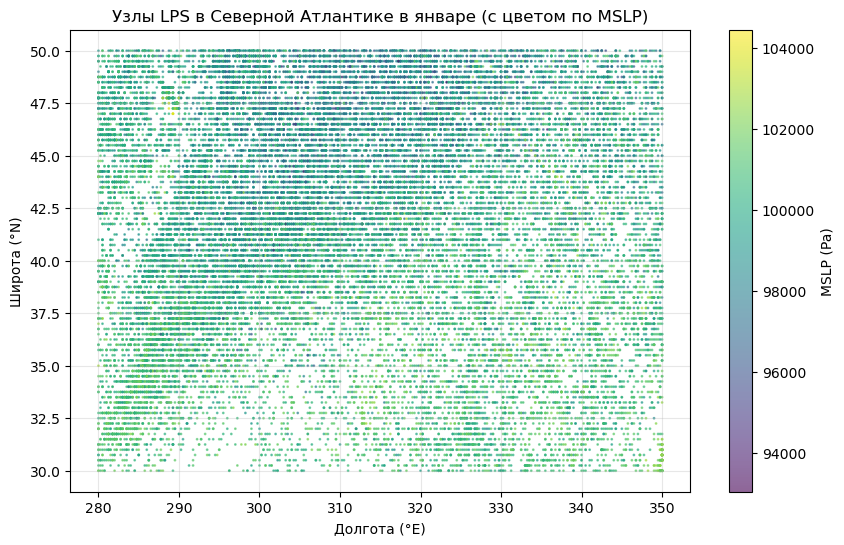

In [10]:
# Task 14: Выбрать узлы в определенном регионе и месяце
# Преобразуем колонку ISOTIME в datetime, если еще не сделано
if df['ISOTIME'].dtype == 'object':
    df['ISOTIME'] = pd.to_datetime(df['ISOTIME'])

# Определим регион (Северная Атлантика) и январь месяц
region_df = df[(df['LAT'] >= 30) & (df['LAT'] <= 50) &
               (df['LON'] >= 280) & (df['LON'] <= 350) &
               (df['ISOTIME'].dt.month == 1)]
print(f"Задание 14: Узлов в Северной Атлантике (30-50°N, 280-350°E) за январь: {len(region_df):,}")

# Визуализация географического распределения
plt.figure(figsize=(10, 6))
plt.scatter(region_df['LON'], region_df['LAT'], c=region_df['MSLP'], 
            s=1, cmap='viridis', alpha=0.6)
plt.colorbar(label='MSLP (Pa)')
plt.xlabel('Долгота (°E)')
plt.ylabel('Широта (°N)')
plt.title('Узлы LPS в Северной Атлантике в январе (с цветом по MSLP)')
plt.grid(alpha=0.3)
plt.show()

## 5. Расширенный анализ (Стадии жизни циклонов)

In [11]:
# Task 5: Выделить TC-стадию для каждого TC-трека (от первого до последнего узла 'TC')
# Создадим копию данных для работы
df_tc = df[df['Track_Info'].str.contains('TC', na=False)].copy()

tc_stage_dfs = []
for tid, group in df_tc.groupby('TID'):
    # Находим индексы (в группе), где метка == 'TC'
    tc_indices_in_group = group.index[group[label_col] == 'TC']
    if len(tc_indices_in_group) >= 1:
        start_idx, end_idx = tc_indices_in_group[0], tc_indices_in_group[-1]
        # Получаем срез из оригинального датафрейма по позиции в группе
        # Для этого лучше использовать порядковые номера в группе
        start_pos = group.index.get_loc(start_idx)
        end_pos = group.index.get_loc(end_idx)
        tc_stage_group = group.iloc[start_pos:end_pos+1]
        tc_stage_dfs.append(tc_stage_group)

if tc_stage_dfs:
    df_tc_stage = pd.concat(tc_stage_dfs)
    print(f"Задание 5: Выделено узлов, соответствующих TC-стадии треков: {len(df_tc_stage):,}")
else:
    print("Задание 5: TC-стадии не найдены.")

Задание 5: Выделено узлов, соответствующих TC-стадии треков: 241,642


## 6. Заключение и дополнительные возможности

Этот ноутбук демонстрирует базовый анализ классифицированного каталога SyCLoPS.

**Что можно сделать дальше:**
- **Анализ треков:** Группировать данные по `TID` и анализировать эволюцию параметров (MSLP, размер) вдоль трека.
- **Сезонность:** Изучать распределение различных типов LPS по месяцам и сезонам.
- **Пространственные карты:** Строить карты плотности треков или средних значений параметров для выбранных типов.
- **Расчет IKE и осадков:** Для углубленного анализа, как описано в разделе 3.2 руководства, потребуется запуск дополнительных скрипов (`Blob_idtag.py` и др.), что выходит за рамки этого ноутбука.

In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Анализ входного каталога SyCLoPS (неклассифицированные параметры LPS)
Файл: SyCLoPS_input_ERA5_1940_2024_3hr.parquet
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================

def load_input_catalog(file_path):
    """
    Загрузка входного каталога SyCLoPS из файла Parquet
    
    Parameters:
    -----------
    file_path : str
        Путь к файлу SyCLoPS_input_ERA5_1940_2024_3hr.parquet
    
    Returns:
    --------
    pd.DataFrame
    """
    print("="*80)
    print("ЗАГРУЗКА ВХОДНОГО КАТАЛОГА SyCLoPS")
    print("="*80)
    
    if not Path(file_path).exists():
        raise FileNotFoundError(f"Файл не найден: {file_path}")
    
    df = pd.read_parquet(file_path)
    print(f"✓ Файл загружен: {file_path}")
    print(f"✓ Количество узлов LPS: {len(df):,}")
    print(f"✓ Количество колонок: {len(df.columns)}")
    print(f"✓ Период данных: {df['ISOTIME'].min()} - {df['ISOTIME'].max()}")
    print(f"✓ Количество уникальных треков (TID): {df['TID'].nunique():,}")
    
    return df

# =============================================================================
# 2. БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ
# =============================================================================

def basic_info(df):
    """
    Вывод базовой информации о данных: типы колонок, пропуски, статистики
    """
    print("\n" + "="*80)
    print("ИНФОРМАЦИЯ О ДАННЫХ")
    print("="*80)
    
    # Типы данных
    print("\n--- Типы данных колонок ---")
    print(df.dtypes)
    
    # Пропуски
    print("\n--- Пропуски в данных (NaN) ---")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(missing)
        print(f"\nВсего колонок с пропусками: {len(missing)}")
    else:
        print("Пропуски отсутствуют.")
    
    # Статистики для числовых колонок
    print("\n--- Основные статистики для числовых колонок ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(df[numeric_cols].describe())
    
    return numeric_cols

# =============================================================================
# 3. АНАЛИЗ РАСПРЕДЕЛЕНИЙ КЛЮЧЕВЫХ ПАРАМЕТРОВ
# =============================================================================

def analyze_parameter_distributions(df, numeric_cols, output_dir='plots'):
    """
    Построение распределений ключевых параметров (гистограммы + boxplot)
    
    Параметры из таблицы 1.3 руководства:
    - MSLP: давление на уровне моря
    - DEEPSHEAR: сдвиг ветра между 200 и 850 гПа
    - RH100MAX: макс. влажность на 100 гПа
    - RH850AVG: средняя влажность на 850 гПа
    - VO500AVG: завихренность на 500 гПа
    - T850: температура на 850 гПа
    """
    Path(output_dir).mkdir(exist_ok=True)
    
    # Ключевые параметры для анализа
    key_params = [
        'MSLP', 'DEEPSHEAR', 'RH100MAX', 
        'RH850AVG', 'VO500AVG', 'T850'
    ]
    
    # Фильтруем только существующие колонки
    key_params = [p for p in key_params if p in df.columns]
    
    print("\n" + "="*80)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ КЛЮЧЕВЫХ ПАРАМЕТРОВ")
    print("="*80)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, param in enumerate(key_params):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        data = df[param].dropna()
        
        # Гистограмма с ядерной оценкой плотности
        sns.histplot(data, kde=True, ax=ax, bins=50, color='steelblue')
        
        # Добавляем статистики
        mean_val = data.mean()
        median_val = data.median()
        ax.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', label=f'Медиана: {median_val:.2f}')
        
        ax.set_title(f'Распределение {param}')
        ax.set_xlabel(param)
        ax.set_ylabel('Частота')
        ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/input_parameters_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ График сохранен: {output_dir}/input_parameters_distribution.png")
    
    # Дополнительный boxplot для выбросов
    fig, axes = plt.subplots(1, len(key_params), figsize=(15, 5))
    if len(key_params) == 1:
        axes = [axes]
    
    for idx, param in enumerate(key_params):
        ax = axes[idx]
        data = df[param].dropna()
        sns.boxplot(x=data, ax=ax, color='lightblue')
        ax.set_title(f'Boxplot: {param}')
        ax.set_xlabel(param)
        
        # Добавляем кол-во выбросов
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
        if len(outliers) > 0:
            ax.text(0.05, 0.95, f'Выбросы: {len(outliers):,}',
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/input_parameters_boxplot.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ График сохранен: {output_dir}/input_parameters_boxplot.png")

# =============================================================================
# 4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# =============================================================================

def correlation_analysis(df, numeric_cols, output_dir='plots'):
    """
    Анализ корреляций между параметрами для понимания взаимосвязей
    """
    print("\n" + "="*80)
    print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
    print("="*80)
    
    # Выбираем только ключевые параметры для упрощения
    key_params = [
        'MSLP', 'DEEPSHEAR', 'RH100MAX', 'RH850AVG', 
        'VO500AVG', 'T850', 'Z850', 'LPSAREA'
    ]
    key_params = [p for p in key_params if p in df.columns]
    
    if len(key_params) < 2:
        print("Недостаточно параметров для корреляционного анализа.")
        return
    
    corr_matrix = df[key_params].corr()
    
    # Вывод корреляционной матрицы
    print("\nКорреляционная матрица:")
    print(corr_matrix.round(3))
    
    # Тепловая карта
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5)
    plt.title('Корреляционная матрица параметров SyCLoPS (входной каталог)')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/input_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ График сохранен: {output_dir}/input_correlation_matrix.png")
    
    # Сильные корреляции (|r| > 0.7)
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.7:
                strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
    
    if strong_corr:
        print("\nСильные корреляции (|r| > 0.7):")
        for param1, param2, r in strong_corr:
            print(f"  {param1} ↔ {param2}: {r:.3f}")

# =============================================================================
# 5. ПРОСТРАНСТВЕННЫЙ АНАЛИЗ
# =============================================================================

def spatial_analysis(df, output_dir='plots'):
    """
    Анализ географического распределения узлов LPS
    """
    print("\n" + "="*80)
    print("ПРОСТРАНСТВЕННЫЙ АНАЛИЗ")
    print("="*80)
    
    # Диапазоны координат
    print(f"\nДиапазон широт: {df['LAT'].min():.2f}° - {df['LAT'].max():.2f}°")
    print(f"Диапазон долгот: {df['LON'].min():.2f}° - {df['LON'].max():.2f}°")
    
    # Карта плотности
    plt.figure(figsize=(12, 6))
    
    # 2D гистограмма для визуализации плотности
    plt.subplot(1, 2, 1)
    h = plt.hist2d(df['LON'], df['LAT'], bins=100, cmap='YlOrRd', cmin=1)
    plt.colorbar(label='Количество узлов')
    plt.xlabel('Долгота (°E)')
    plt.ylabel('Широта (°N)')
    plt.title('Плотность узлов LPS')
    plt.grid(alpha=0.3)
    
    # Scatter plot с цветом по MSLP
    plt.subplot(1, 2, 2)
    # Выбираем случайную подвыборку для производительности
    sample_size = min(100000, len(df))
    sample = df.sample(sample_size)
    scatter = plt.scatter(sample['LON'], sample['LAT'], 
                         c=sample['MSLP'], s=1, cmap='viridis', alpha=0.5)
    plt.colorbar(scatter, label='MSLP (Pa)')
    plt.xlabel('Долгота (°E)')
    plt.ylabel('Широта (°N)')
    plt.title(f'Распределение MSLP (случайная выборка {sample_size:,} узлов)')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/input_spatial_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ График сохранен: {output_dir}/input_spatial_distribution.png")

# =============================================================================
# 6. ВРЕМЕННОЙ АНАЛИЗ
# =============================================================================

def temporal_analysis(df, output_dir='plots'):
    """
    Анализ временных рядов: количество узлов по годам и месяцам
    """
    print("\n" + "="*80)
    print("ВРЕМЕННОЙ АНАЛИЗ")
    print("="*80)
    
    # Извлекаем год и месяц
    df['YEAR'] = df['ISOTIME'].dt.year
    df['MONTH'] = df['ISOTIME'].dt.month
    df['YEAR_MONTH'] = df['ISOTIME'].dt.to_period('M')
    
    # Количество узлов по годам
    yearly_counts = df.groupby('YEAR').size()
    
    print("\nСтатистика по годам:")
    print(f"  Минимум узлов в год: {yearly_counts.min():,} ({yearly_counts.idxmin()})")
    print(f"  Максимум узлов в год: {yearly_counts.max():,} ({yearly_counts.idxmax()})")
    print(f"  Среднее узлов в год: {yearly_counts.mean():.0f}")
    
    # График годового тренда
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Годовой тренд
    ax1.plot(yearly_counts.index, yearly_counts.values, 'o-', color='steelblue', linewidth=1.5, markersize=4)
    ax1.set_title('Количество узлов LPS по годам (входной каталог)')
    ax1.set_xlabel('Год')
    ax1.set_ylabel('Количество узлов')
    ax1.grid(alpha=0.3)
    
    # Сезонность по месяцам
    monthly_counts = df.groupby('MONTH').size()
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
              'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    ax2.bar(months, monthly_counts.values, color='coral', alpha=0.7)
    ax2.set_title('Сезонное распределение узлов LPS')
    ax2.set_xlabel('Месяц')
    ax2.set_ylabel('Количество узлов')
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/input_temporal_analysis.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ График сохранен: {output_dir}/input_temporal_analysis.png")
    
    return yearly_counts

# =============================================================================
# 7. АНАЛИЗ ПАРАМЕТРОВ ПО РЕГИОНАМ
# =============================================================================

def regional_analysis(df, output_dir='plots'):
    """
    Анализ параметров по климатическим зонам (тропики, умеренные широты)
    """
    print("\n" + "="*80)
    print("РЕГИОНАЛЬНЫЙ АНАЛИЗ")
    print("="*80)
    
    # Определяем регионы
    df['REGION'] = 'Умеренные широты'
    df.loc[(df['LAT'] >= -30) & (df['LAT'] <= 30), 'REGION'] = 'Тропики'
    df.loc[df['LAT'] > 60, 'REGION'] = 'Арктика/Антарктика'
    df.loc[df['LAT'] < -60, 'REGION'] = 'Арктика/Антарктика'
    
    print("\nРаспределение узлов по регионам:")
    region_counts = df['REGION'].value_counts()
    for region, count in region_counts.items():
        print(f"  {region}: {count:,} ({count/len(df)*100:.1f}%)")
    
    # Сравнение параметров по регионам
    key_params = ['MSLP', 'DEEPSHEAR', 'RH100MAX', 'RH850AVG', 'T850']
    key_params = [p for p in key_params if p in df.columns]
    
    if len(key_params) > 0:
        fig, axes = plt.subplots(1, len(key_params), figsize=(15, 5))
        if len(key_params) == 1:
            axes = [axes]
        
        for idx, param in enumerate(key_params):
            ax = axes[idx]
            data_by_region = [df[df['REGION'] == region][param].dropna() 
                            for region in df['REGION'].unique()]
            bp = ax.boxplot(data_by_region, labels=df['REGION'].unique(), 
                           patch_artist=True)
            for patch in bp['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.7)
            ax.set_title(f'{param} по регионам')
            ax.set_ylabel(param)
            ax.grid(alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/input_regional_parameters.png', dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✓ График сохранен: {output_dir}/input_regional_parameters.png")
    
    # Возвращаем df с регионом для дальнейшего использования
    return df

# =============================================================================
# 8. ГЛАВНАЯ ФУНКЦИЯ
# =============================================================================

def main():
    """
    Главная функция для запуска полного анализа
    """

    INPUT_FILE = f'{path_dir_data}/SyCLoPS/SyCLoPS_input_ERA5_1940_2024_3hr.parquet'
    
    # Параметры
    OUTPUT_DIR = f'{path_dir_data}/SyCLoPS/input_analysis_results'
    
    try:
        # 1. Загрузка данных
        df = load_input_catalog(INPUT_FILE)
        
        # 2. Базовая информация
        numeric_cols = basic_info(df)
        
        # 3. Распределения параметров
        analyze_parameter_distributions(df, numeric_cols, OUTPUT_DIR)
        
        # 4. Корреляционный анализ
        correlation_analysis(df, numeric_cols, OUTPUT_DIR)
        
        # 5. Пространственный анализ
        spatial_analysis(df, OUTPUT_DIR)
        
        # 6. Временной анализ
        yearly_counts = temporal_analysis(df, OUTPUT_DIR)
        
        # 7. Региональный анализ
        df_with_region = regional_analysis(df, OUTPUT_DIR)
        
        # 8. Дополнительная статистика по трекам
        print("\n" + "="*80)
        print("СТАТИСТИКА ПО ТРЕКАМ")
        print("="*80)
        track_stats = df.groupby('TID').agg({
            'LON': ['count', 'min', 'max'],
            'LAT': ['min', 'max'],
            'MSLP': ['min', 'mean']
        })
        print(f"Количество треков: {len(track_stats):,}")
        print(f"Средняя длина трека (узлов): {track_stats[('LON', 'count')].mean():.1f}")
        print(f"Медианная длина трека: {track_stats[('LON', 'count')].median():.0f}")
        print(f"Максимальная длина трека: {track_stats[('LON', 'count')].max():,}")
        
        # 9. Сохранение обработанных данных
        output_file = f'{OUTPUT_DIR}/input_catalog_with_region.parquet'
        df_with_region.to_parquet(output_file)
        print(f"\n✓ Обработанные данные сохранены: {output_file}")
        
        print("\n" + "="*80)
        print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!")
        print("="*80)
        print(f"Результаты сохранены в папке: {OUTPUT_DIR}/")
        
    except FileNotFoundError as e:
        print(f"\n❌ ОШИБКА: {e}")
        print("Пожалуйста, проверьте путь к файлу и повторите попытку.")
    except Exception as e:
        print(f"\n❌ НЕПРЕДВИДЕННАЯ ОШИБКА: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

ЗАГРУЗКА ВХОДНОГО КАТАЛОГА SyCLoPS
✓ Файл загружен: /storage/thalassa/users/vkoshkina/data//SyCLoPS/SyCLoPS_input_ERA5_1940_2024_3hr.parquet
✓ Количество узлов LPS: 12,685,049
✓ Количество колонок: 33
✓ Период данных: 1940-01-01 00:00:00 - 2024-12-31 21:00:00
✓ Количество уникальных треков (TID): 628,024

ИНФОРМАЦИЯ О ДАННЫХ

--- Типы данных колонок ---
TID                         int64
ISOTIME            datetime64[ns]
i                           int64
j                           int64
LON                       float64
                        ...      
Transition_Zone           float64
Tropical_Flag             float64
distance                  float64
direction                 float64
distance_2steps           float64
Length: 33, dtype: object

--- Пропуски в данных (NaN) ---
distance_2steps    1096921
distance            547009
direction           547009
dtype: int64

Всего колонок с пропусками: 3

--- Основные статистики для числовых колонок ---
                TID             i   